In [1]:
colab = False
if colab:
    !git clone https://github.com/mdrs-thiago/PUC_Redes_Neurais
    import os
    os.chdir('/content/PUC_Redes_Neurais/pos_grad/lista 1')

# Redes Neurais
## 1ª Lista de Exercícios - Classificação de padrões


Estudante: Carlos ALberto de Souza Moreria Junior Matrícula: 2612398

Base de dados: bank marketing

### Para cada item da lista de exercício, não esqueça de fazer uma análise pertinente dos resultados obtidos.

### Guia prático



A lista de exercícios é dividida em 4 partes. Cada questão possui as seguintes seções:



* **Rascunho**: neste espaço, você pode escrever qualquer código ou teste que queira fazer, mas que *não* produza a resposta desejada.



* **Resposta**: deve conter trechos do código que produzam artefatos importantes para a análise de resultados, além de comentários e discussões sobre o item.



Não é necessário seguir esta ordem, mas é *altamente recomendável*. O intuito da lista de exercícios **não** é medir o nível de conhecimento em programação, então não se preocupe se o código não estiver da forma mais polida possível. O principal ponto a ser avaliado é a capacidade crítica de entender os fenômenos atrelados aos resultados obtidos e a discussão de resultados para um problema específico.   



Outros pontos importantes:



1. Fique atento com os hiperparâmetros iniciais desta lista. Dependendo do problema, os valores podem mudar. Para encontrar um conjunto de parâmetros razoáveis, siga o seguinte roteiro: 



    * Rode os itens 2.1 e 3.1 com os parâmetros iniciais. Se os dois resultados foram igualmente ruins, modifique os parâmetros do item 3.1 até que o resultado seja relativamente melhor que o 2.1.



    * Após obter esses melhores parâmetros iniciais, rode novamente o item 2.1 com os mesmos hiperparâmetros para uma comparação mais justa. 



2. O resultado de um modelo de Redes Neurais geralmente depende da inicialização de seus pesos. Portanto, para cada questão, obtenha um resultado médio de pelo menos 10 rodadas. A recomendação pessoal é de que faça uso do histórico existente da perda (loss) e acurácia para visualização dos resultados, com plot da média e seu intervalo de confiança em função das épocas.

In [2]:
import numpy as np 
import pandas as pd 
import json
import matplotlib.pyplot as plt 
import seaborn as sns 
from time import sleep
import requests

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from utils import CustomDataset, transform_data, plot_confusion_matrix

from typing import Tuple, Dict, List
from tqdm import tqdm 

In [3]:
def accuracy(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    _, predictions = torch.max(y_pred, dim=1)
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

def binary_acc(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the binary accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    predictions = torch.round(torch.sigmoid(y_pred))
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

In [4]:
def evaluate(model: torch.nn.Module, val_set: Tuple[torch.tensor, torch.tensor], 
            criterion: torch.nn.Module, binary:bool =True) -> Tuple[torch.tensor, float, float]:
    """
    Evaluates a Pytorch model on a given dataset.
    Parameters:
    model (torch.nn.Module): The model to be evaluated
    data (tuple): A tuple containing the data and labels
    criterion (torch.nn.Module): The loss function to be used
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    Returns:
    tuple: A tuple containing predicted labels, loss, and accuracy
    """
    
    X = val_set.X_data
    y = val_set.y_data
    
    with torch.no_grad():
        y_pred = model(X)
    loss = criterion(y_pred, y)
    if binary:
        acc = binary_acc(y_pred, y)
    else:
        acc = accuracy(y_pred, y)
    y_pred = torch.argmax(y_pred, dim=1)

    return y_pred, loss.item(), acc.item()


In [5]:
def train(model: torch.nn.Module , train_loader: torch.utils.data.DataLoader, 
         val_set: Tuple[torch.Tensor, torch.Tensor], epochs: int, device: torch.device, 
         lr: float, binary: bool = True, skip: int = 1) -> Tuple[Dict[str, List[float]], torch.Tensor]:
    """
    Trains a Pytorch model on a given training data.

    Parameters:
    model (torch.nn.Module): The model to be trained
    train_loader (DataLoader): The training data in the form of a Pytorch DataLoader
    val_set (tuple): A tuple containing the validation data and labels
    epochs (int): The number of times the training data should be passed through the model
    device (str or torch.device): The device on which to perform the computations (e.g. 'cpu' or 'cuda')
    lr (float): The learning rate for the optimizer
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    skip (int): The number of epochs after which the training and validation results will be printed. Default: 1

    Returns:
    tuple: A tuple containing the training history and the predicted labels after training
    """

    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {'acc_train' : [], 'loss_train': [], 'acc_val': [], 'loss_val': []}

    for e in tqdm(range(1, epochs+1)):

        y_hat = np.array([])

        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()
            
            y_pred = model(X)
            
            loss = criterion(y_pred, y)
            if binary:
                acc = binary_acc(y_pred,y)
            else:
                acc = accuracy(y_pred, y)
            
            loss.backward()
            optimizer.step()
            
            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()
            y_p = torch.argmax(y_pred, dim=1)
            y_hat = np.concatenate((y_hat, y_p))


        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)

        history['acc_train'].append(train_epoch_acc/len(train_loader))
        history['loss_train'].append(train_epoch_loss/len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)

        if e%skip == 0:
            print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')
    return history, y_hat

In [6]:
class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um 
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar 
  o mesmo modelo com apenas uma linha.
  
  Parâmetros de entrada: 
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida. 
  - hidden_activation: Função de ativação para cada camada escondida. Aceita 
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma 
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  '''
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', output_activation='softmax', lr = 0.05, n_input = 1, n_output = 1):
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)

  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h) 
    y = self.fc2(h1) 
    return y

  def predict(self, x, binary=True):
    y_hat = self.forward(x)

    if binary:
      y_pred = torch.round(torch.sigmoid(y_hat))
      y_pred = y_pred.detach().numpy()
    else:
      y_pred = torch.argmax(y_hat, dim=1)

    return y_pred

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/carlos/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


# Preparação dos dados

Não esqueça de verificar o path para a pasta. Mude também o filename, de acordo com a base de dados. Esta parte é necessária para garantir que as colunas sejam corretamente identificadas de acordo com a natureza dos dados.

In [8]:
dataset_name = 'bank_marketing'
base_raw = 'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets'
dataset_path = f'{base_raw}/c_{dataset_name}.csv'
info_path = f'{base_raw}/data_info/{dataset_name}/data_info.json'
local_dataset_path = f'../../datasets/c_{dataset_name}.csv'

#não consegui acessar direto o  dataset
try:
    dataset = pd.read_csv(dataset_path)
except Exception:
    if dataset_name == 'bank_marketing':
        from io import BytesIO
        from zipfile import ZipFile

        uci_bank_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'
        zip_bytes = requests.get(uci_bank_url, timeout=30).content
        with ZipFile(BytesIO(zip_bytes)) as zf:
            with zf.open('bank-full.csv') as f:
                dataset = pd.read_csv(f, sep=';')
    else:
        dataset = pd.read_csv(local_dataset_path)

if 'y' in dataset.columns and 'target' not in dataset.columns:
    dataset = dataset.rename(columns={'y': 'target'})

In [9]:
local_info_path = f'../../datasets/data_info/{dataset_name}/data_info.json'

try:
    resp = requests.get(info_path, timeout=20)
    resp.raise_for_status()
    info = json.loads(resp.text)
except Exception:
    with open(local_info_path, 'r') as f:
        info = json.load(f)

if 'y' in info and 'target' not in info:
    info['target'] = info.pop('y')

In [10]:
for col, k in info.items():
    if k == 'categorical' and col in dataset.columns:
        dataset[col] = dataset[col].astype(object)

In [11]:
for i in dataset.dtypes.items():
    print(i)

('age', dtype('int64'))
('job', dtype('O'))
('marital', dtype('O'))
('education', dtype('O'))
('default', dtype('O'))
('balance', dtype('int64'))
('housing', dtype('O'))
('loan', dtype('O'))
('contact', dtype('O'))
('day', dtype('int64'))
('month', dtype('O'))
('duration', dtype('int64'))
('campaign', dtype('int64'))
('pdays', dtype('int64'))
('previous', dtype('int64'))
('poutcome', dtype('O'))
('target', dtype('O'))


In [12]:
# Visao geral do dataset bank_marketing
print(f"Dataset selecionado: {dataset_name}")
print(f"Dimensao: {dataset.shape[0]} linhas x {dataset.shape[1]} colunas")

print("\nPrimeiras 5 linhas:")
display(dataset.head())

print("\nInformacoes das colunas:")
display(dataset.dtypes.to_frame(name='dtype').T)

if 'target' in dataset.columns:
    print("\nDistribuicao da variavel alvo (target):")
    display(dataset['target'].value_counts(dropna=False).to_frame(name='count').T)

Dataset selecionado: bank_marketing
Dimensao: 45211 linhas x 17 colunas

Primeiras 5 linhas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Informacoes das colunas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
dtype,int64,object,object,object,object,int64,object,object,object,int64,object,int64,int64,int64,int64,object,object



Distribuicao da variavel alvo (target):


target,no,yes
count,39922,5289


## Parte I - Compreensão do problema e análise de variáveis

Total: 0,5 pts.


1)	Neste primeiro momento, iremos verificar a qualidade dos dados. Verifique se os dados estão aptos para o treinamento de Redes Neurais (i.e., verifique a existência de dados nulos, atributos de identificação ou duplicados). Implemente o código que execute as técnicas necessárias e discuta o racional utilizado para o tratamento de dados. 

#### Rascunho

In [13]:
# PSEUDOCODIGO (Rascunho)
# 1. Inspecionar dimensao da base e tipos das colunas.
# 2. Verificar dados nulos por coluna.
# 3. Verificar duplicatas completas e remover, se houver.
# 4. Procurar colunas candidatas a identificador (nome com "id" ou alta cardinalidade).
# 5. Definir estrategia de tratamento e aplicar no dataset.



Resposta

In [14]:
# Questao 1 - Implementacao com saidas explicitas por etapa do pseudocodigo

def check_data_quality(df: pd.DataFrame, target_col: str = 'target', id_threshold: float = 0.98) -> dict:
    nulls = df.isna().sum()
    n_duplicates = int(df.duplicated().sum())

    id_candidates = []
    for col in df.columns:
        if col == target_col:
            continue
        unique_ratio = df[col].nunique(dropna=False) / max(len(df), 1)
        if ('id' in col.lower()) or (unique_ratio >= id_threshold):
            id_candidates.append(col)

    target_dist = None
    if target_col in df.columns:
        target_dist = df[target_col].value_counts(dropna=False)

    return {
        'shape': df.shape,
        'dtypes': df.dtypes,
        'nulls': nulls,
        'n_duplicates': n_duplicates,
        'id_candidates': id_candidates,
        'target_dist': target_dist
    }


def clean_data_for_nn(df: pd.DataFrame, target_col: str = 'target', drop_id_candidates: bool = True,
                      id_threshold: float = 0.98) -> tuple[pd.DataFrame, dict]:
    df_clean = df.copy()
    report_before = check_data_quality(df_clean, target_col=target_col, id_threshold=id_threshold)

    if report_before['n_duplicates'] > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)

    removed_cols = []
    if drop_id_candidates and report_before['id_candidates']:
        removed_cols = [c for c in report_before['id_candidates'] if c in df_clean.columns]
        if removed_cols:
            df_clean = df_clean.drop(columns=removed_cols)

    report_after = check_data_quality(df_clean, target_col=target_col, id_threshold=id_threshold)
    report_after['removed_id_cols'] = removed_cols

    return df_clean, {'before': report_before, 'after': report_after}


# Executa analise
cleaned_dataset_q1, quality_report_q1 = clean_data_for_nn(
    dataset,
    target_col='target',
    drop_id_candidates=True
)

# 1) Inspecionar dimensao da base e tipos das colunas
print('1) INSPECAO INICIAL DA BASE')
print(f"- Dimensao inicial: {quality_report_q1['before']['shape'][0]} linhas x {quality_report_q1['before']['shape'][1]} colunas")
print('- Tipos das colunas (amostra):')
print(quality_report_q1['before']['dtypes'].head(10))

# 2) Verificar dados nulos por coluna
print('\n2) DADOS NULOS')
nulls_before = quality_report_q1['before']['nulls']
nulls_nonzero = nulls_before[nulls_before > 0]
if len(nulls_nonzero) == 0:
    print('- Nao foram encontrados valores nulos explicitos.')
else:
    print('- Colunas com nulos:')
    print(nulls_nonzero)

# 3) Verificar duplicatas completas e remover, se houver
print('\n3) DUPLICATAS')
print(f"- Duplicatas completas antes: {quality_report_q1['before']['n_duplicates']}")
print(f"- Duplicatas completas depois: {quality_report_q1['after']['n_duplicates']}")
if quality_report_q1['before']['n_duplicates'] > 0:
    print('- Acao: duplicatas removidas com drop_duplicates().')
else:
    print('- Acao: nenhuma remocao necessaria.')

# 4) Procurar colunas candidatas a identificador
print('\n4) ATRIBUTOS CANDIDATOS A IDENTIFICADOR')
print(f"- Candidatas encontradas: {quality_report_q1['before']['id_candidates']}")
print(f"- Colunas efetivamente removidas: {quality_report_q1['after']['removed_id_cols']}")

# 5) Verificar distribuicao da variavel-alvo (desbalanceamento)
print('\n5) DISTRIBUICAO DA VARIAVEL-ALVO')
target_dist = quality_report_q1['after']['target_dist']
if target_dist is not None:
    target_pct = (target_dist / target_dist.sum() * 100).round(2)
    print('- Contagem por classe:')
    print(target_dist)
    print('- Percentual por classe (%):')
    print(target_pct)

    if len(target_dist) >= 2:
        maj = target_dist.max()
        minv = target_dist.min()
        imbalance_ratio = maj / max(minv, 1)
        print(f'- Razao majoritaria/minoritaria: {imbalance_ratio:.2f}')
        if imbalance_ratio >= 2.0:
            print('- Observacao: ha desbalanceamento relevante; accuracy isolada pode ser enganosa.')
        else:
            print('- Observacao: desbalanceamento baixo ou moderado.')

# 6) Definir estrategia de tratamento e aplicar no dataset
print('\n6) ESTRATEGIA APLICADA')
print('- Estrategia: remover duplicatas e remover possiveis identificadores (quando encontrados).')
print('- Ressalva: categorias como "unknown" e o possivel desbalanceamento da classe-alvo exigem cuidado na analise.')
print(f"- Dimensao final apos tratamento: {quality_report_q1['after']['shape'][0]} linhas x {quality_report_q1['after']['shape'][1]} colunas")

# Atualiza base para os proximos itens
dataset = cleaned_dataset_q1.copy()
print('\nConclusao da Questao 1: base utilizavel para as proximas etapas, com ressalvas sobre categorias "unknown" e sobre o desbalanceamento da classe-alvo.')

1) INSPECAO INICIAL DA BASE
- Dimensao inicial: 45211 linhas x 17 colunas
- Tipos das colunas (amostra):
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
dtype: object

2) DADOS NULOS
- Nao foram encontrados valores nulos explicitos.

3) DUPLICATAS
- Duplicatas completas antes: 0
- Duplicatas completas depois: 0
- Acao: nenhuma remocao necessaria.

4) ATRIBUTOS CANDIDATOS A IDENTIFICADOR
- Candidatas encontradas: []
- Colunas efetivamente removidas: []

5) DISTRIBUICAO DA VARIAVEL-ALVO
- Contagem por classe:
target
no     39922
yes     5289
Name: count, dtype: int64
- Percentual por classe (%):
target
no     88.3
yes    11.7
Name: count, dtype: float64
- Razao majoritaria/minoritaria: 7.55
- Observacao: ha desbalanceamento relevante; accuracy isolada pode ser enganosa.

6) ESTRATEGIA APLICADA
- Estrategia: remover duplicatas e remover po

## Comentarios

Nesta etapa, a análise mostrou que a base está estruturalmente apta para o treinamento, pois foram identificadas 45.211 observações e 17 colunas, sem presença de valores nulos explícitos, sem duplicatas completas e sem atributos claramente caracterizados como identificadores. Isso é importante porque garante que o modelo não será treinado sobre uma base com problemas básicos de consistência, o que já seria uma fonte de erro antes mesmo da etapa de modelagem.

Ao mesmo tempo, a inspeção inicial já revelou um ponto relevante para as próximas partes: a variável-alvo é bastante desbalanceada, com cerca de 88,3% da classe “no” e 11,7% da classe “yes”. Isso significa que, mesmo com a base limpa, o problema não é trivial, pois um modelo pode apresentar boa acurácia apenas por favorecer a classe majoritária. Além disso, categorias como unknown não aparecem como nulos formais, mas ainda exigem leitura cuidadosa, pois podem representar ausência parcial de informação.

2) Utilize técnicas de seleção de variáveis e visualização de gráficos para compreender melhor a relação entre as variáveis do problema. Avalie e discuta os resultados obtidos. 

Rascunho

In [15]:
# PSEUDOCODIGO (Rascunho)
# 1. Converter variaveis categoricas para formato numerico (one-hot/label).
# 2. Medir relevancia de atributos para o alvo (correlacao e informacao mutua).
# 3. Visualizar relacoes mais fortes com heatmap.
# 4. Selecionar subconjunto de atributos mais informativos para analise.

Resposta



1) CONVERSAO DE VARIAVEIS CATEGORICAS
- Total de variaveis originais (sem alvo): 16
- Variaveis categoricas: 9
- Variaveis numericas: 7
- Total de variaveis apos one-hot: 51
- Exemplo de colunas apos codificacao:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services']

1.1) REDUNDANCIA EM PARES ONE-HOT COMPLEMENTARES
- Foram encontrados 3 pares binarios potencialmente redundantes.
- Exemplos (par e correlacao):
  default_no x default_yes | corr=-1.0000
  housing_no x housing_yes | corr=-1.0000
  loan_no x loan_yes | corr=-1.0000
- Observacao: esses pares carregam informacao espelhada e podem inflar redundancia.

2) RELEVANCIA DAS VARIAVEIS (CORRELACAO E INFORMACAO MUTUA)
- Top 12 por informacao mutua:
duration            0.072502
poutcome_success    0.027459
pdays               0.025470
balance             0.021049
poutcome_unknown  

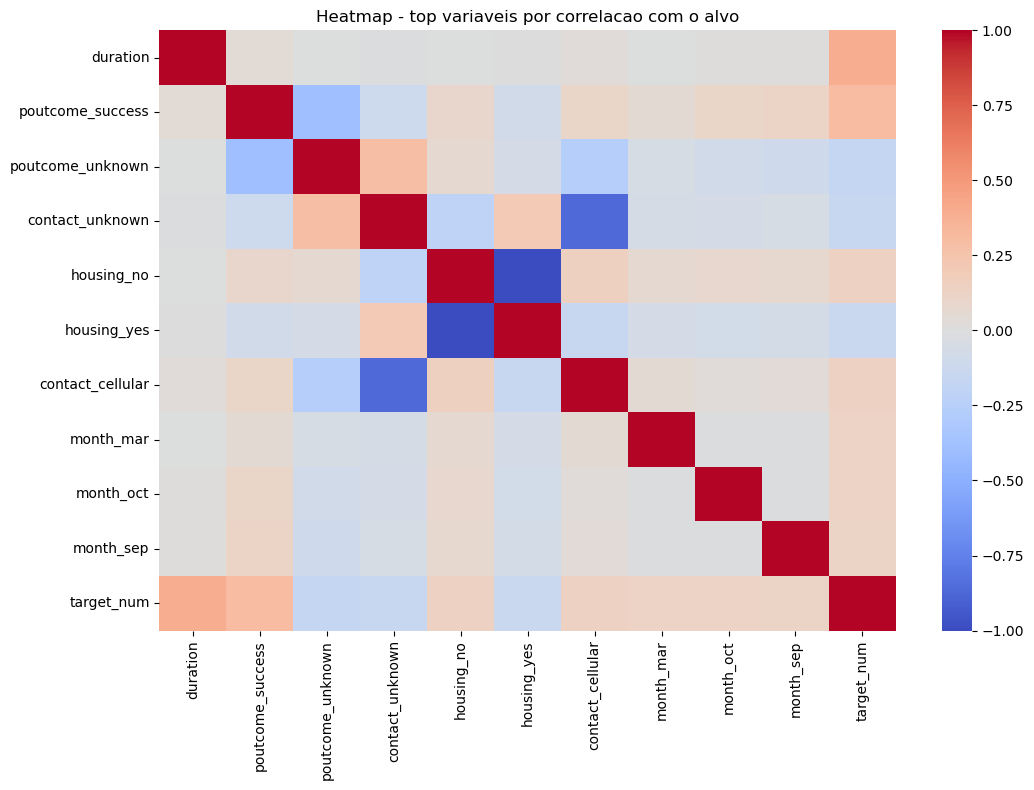


4) SUBCONJUNTO DE ATRIBUTOS MAIS INFORMATIVOS
- Quantidade de atributos selecionados: 10
- Atributos selecionados:
['balance', 'contact_cellular', 'contact_unknown', 'duration', 'housing_no', 'housing_yes', 'month_mar', 'pdays', 'poutcome_success', 'poutcome_unknown']

- Ranking combinado (top 15):


,mi_score,abs_corr_target
duration,0.072502,0.394521
poutcome_success,0.027459,0.306788
pdays,0.025470,0.103621
balance,0.021049,0.052838
poutcome_unknown,0.020584,0.167051
contact_cellular,0.016865,0.135873
contact_unknown,0.016556,0.150935
housing_no,0.015400,0.139173
housing_yes,0.014534,0.139173
age,0.012051,0.025155



Conclusao da Questao 2: MI e correlacao trouxeram visoes complementares, com alerta para redundancia do one-hot e para interpretacao cuidadosa de variaveis muito fortes como duration.


In [16]:
# Questao 2 - Implementacao completa (selecao de variaveis e visualizacao)

from sklearn.feature_selection import mutual_info_classif


# Copia da base para analise
q2_df = dataset.copy()
target_col = 'target'

if target_col not in q2_df.columns:
    raise ValueError(f"Coluna alvo '{target_col}' nao encontrada no dataset.")

# 1) Converter variaveis categoricas para formato numerico (one-hot/label)
print('1) CONVERSAO DE VARIAVEIS CATEGORICAS')
feature_df = q2_df.drop(columns=[target_col]).copy()

cat_cols = feature_df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in feature_df.columns if c not in cat_cols]

print(f'- Total de variaveis originais (sem alvo): {feature_df.shape[1]}')
print(f'- Variaveis categoricas: {len(cat_cols)}')
print(f'- Variaveis numericas: {len(num_cols)}')

X_q2 = pd.get_dummies(feature_df, columns=cat_cols, drop_first=False)
y_q2 = LabelEncoder().fit_transform(q2_df[target_col])

print(f'- Total de variaveis apos one-hot: {X_q2.shape[1]}')
print('- Exemplo de colunas apos codificacao:')
print(X_q2.columns[:15].tolist())

# 1.1) Checar possiveis redundancias em pares complementares do one-hot
print('\n1.1) REDUNDANCIA EM PARES ONE-HOT COMPLEMENTARES')
complementary_pairs = []
for col in cat_cols:
    vals = sorted(feature_df[col].dropna().astype(str).unique().tolist())
    if len(vals) == 2:
        c1 = f'{col}_{vals[0]}'
        c2 = f'{col}_{vals[1]}'
        if c1 in X_q2.columns and c2 in X_q2.columns:
            pair_corr = X_q2[[c1, c2]].corr().iloc[0, 1]
            complementary_pairs.append((col, c1, c2, pair_corr))

if complementary_pairs:
    print(f'- Foram encontrados {len(complementary_pairs)} pares binarios potencialmente redundantes.')
    print('- Exemplos (par e correlacao):')
    for item in complementary_pairs[:5]:
        print(f'  {item[1]} x {item[2]} | corr={item[3]:.4f}')
    print('- Observacao: esses pares carregam informacao espelhada e podem inflar redundancia.')
else:
    print('- Nenhum par complementar binario detectado automaticamente.')

# 2) Medir relevancia de atributos para o alvo (correlacao e informacao mutua)
print('\n2) RELEVANCIA DAS VARIAVEIS (CORRELACAO E INFORMACAO MUTUA)')

mi_values = mutual_info_classif(X_q2.values, y_q2, random_state=42)
mi_series = pd.Series(mi_values, index=X_q2.columns).sort_values(ascending=False)

corr_q2 = X_q2.copy()
corr_q2['target_num'] = y_q2
corr_target = corr_q2.corr(numeric_only=True)['target_num'].drop('target_num').abs().sort_values(ascending=False)

top_n = 12
top_mi = mi_series.head(top_n)
top_corr = corr_target.head(top_n)

print(f'- Top {top_n} por informacao mutua:')
print(top_mi)
print(f'\n- Top {top_n} por |correlacao| com o alvo:')
print(top_corr)

# 2.1) Alerta interpretativo para variavel duration
print('\n2.1) ALERTA INTERPRETATIVO PARA VARIAVEL DURATION')
duration_cols = [c for c in X_q2.columns if c == 'duration' or c.startswith('duration_')]
if duration_cols:
    duration_in_top_mi = [c for c in duration_cols if c in top_mi.index]
    duration_in_top_corr = [c for c in duration_cols if c in top_corr.index]
    print(f'- Colunas relacionadas a duration detectadas: {duration_cols[:3]}')
    if duration_in_top_mi or duration_in_top_corr:
        print('- Duration aparece entre as variaveis mais fortes no ranking.')
        print('- Observacao: isso pode elevar desempenho por proximidade com o desfecho e exige cuidado de interpretacao.')
    else:
        print('- Duration nao apareceu no top atual, mas ainda deve ser monitorada em analises futuras.')
else:
    print('- Nao ha coluna duration identificada apos preprocessamento.')

# 3) Visualizar relacoes mais fortes com heatmap
print('\n3) HEATMAP DAS RELACOES MAIS FORTES')
top_heat_cols = top_corr.head(10).index.tolist()
heat_df = corr_q2[top_heat_cols + ['target_num']].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(heat_df, cmap='coolwarm', center=0, annot=False)
plt.title('Heatmap - top variaveis por correlacao com o alvo')
plt.tight_layout()
plt.show()

# 4) Selecionar subconjunto de atributos mais informativos para analise
print('\n4) SUBCONJUNTO DE ATRIBUTOS MAIS INFORMATIVOS')
selected_features_q2 = sorted(set(top_mi.head(8).index.tolist() + top_corr.head(8).index.tolist()))
X_selected_q2 = X_q2[selected_features_q2].copy()

print(f'- Quantidade de atributos selecionados: {len(selected_features_q2)}')
print('- Atributos selecionados:')
print(selected_features_q2)

ranking_q2 = pd.DataFrame({
    'mi_score': mi_series,
    'abs_corr_target': corr_target.reindex(mi_series.index).fillna(0)
}).sort_values(['mi_score', 'abs_corr_target'], ascending=False)

print('\n- Ranking combinado (top 15):')
display(ranking_q2.head(15))

print('\nConclusao da Questao 2: MI e correlacao trouxeram visoes complementares, com alerta para redundancia do one-hot e para interpretacao cuidadosa de variaveis muito fortes como duration.')

## Comentarios

Nesta etapa, a combinacao de informacao mutua e correlacao foi adequada para identificar variaveis relevantes sem depender de um unico criterio. Os resultados apontaram sinal forte em atributos como duration, poutcome_success, pdays e balance, o que ajuda a justificar as escolhas de variaveis para as proximas fases do trabalho.

O heatmap foi importante para ir alem do ranking numerico: ele permite enxergar blocos de associacao entre variaveis, detectar redundancias e visualizar pares quase espelhados (como colunas one-hot complementares). Em termos práticos, ele ajuda a separar variaveis realmente informativas de estruturas repetidas da codificacao.

Para deixar a interpretacao mais madura, vale incluir explicitamente um teste adicional sem a variavel duration e comparar o ranking de importancia (MI/correlacao) com e sem ela. Se o ranking permanecer semelhante, a conclusao ganha robustez; se mudar muito, isso sinaliza dependencia excessiva de uma unica variavel e exige maior cautela na leitura dos resultados.

## Parte II. Treinamento do modelo de Rede Neural - Baseline e Efeito da Normalização 

Total: 1,5 pts.

In [17]:
# Helper geral para retreinar o modelo do zero com hiperparametros customizados.
# A ideia e: preprocessar -> dividir dados -> treinar -> selecionar melhor epoca -> avaliar no teste.

from sklearn.metrics import classification_report, confusion_matrix


def train_from_scratch(
    dataset_df: pd.DataFrame,
    normalize: bool = True,
    epochs: int = 80,
    lr: float = 0.01,
    hidden_neurons: int = 24,
    batch_size: int = 64,
    momentum: float = 0.0,
    optimizer_name: str = 'sgd',
    patience: int | None = None,
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.2
) -> dict:
    # 1) Reprodutibilidade: fixa sementes para numpy e pytorch.
    np.random.seed(seed)
    torch.manual_seed(seed)

    # 2) Pre-processamento: aplica transform_data (com ou sem normalizacao).
    #    Assume que a ultima coluna e o target.
    df_proc = transform_data(dataset_df, normalize=normalize)
    X_all = df_proc.values[:, :-1].astype('float32')
    y_all = LabelEncoder().fit_transform(df_proc.values[:, -1])

    # 3) Split estratificado: primeiro treino/teste, depois treino/validacao.
    #    Estratificar preserva a proporcao das classes em cada subconjunto.
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=test_size, random_state=seed, stratify=y_all
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, random_state=seed, stratify=y_train
    )

    # 4) Detecta se o problema e binario e define dimensoes de entrada/saida.
    binary_mode = len(np.unique(y_all)) <= 2
    n_input = X_all.shape[1]
    n_output = 1 if binary_mode else len(np.unique(y_all))

    # 5) Converte arrays para tensores no formato correto para cada tipo de problema.
    #    Binario usa float + unsqueeze(1); multiclass usa labels long.
    if binary_mode:
        train_ds = CustomDataset(
            torch.from_numpy(X_train).float(),
            torch.from_numpy(y_train).float().unsqueeze(1)
        )
        val_ds = CustomDataset(
            torch.from_numpy(X_val).float(),
            torch.from_numpy(y_val).float().unsqueeze(1)
        )
        test_ds = CustomDataset(
            torch.from_numpy(X_test).float(),
            torch.from_numpy(y_test).float().unsqueeze(1)
        )
    else:
        train_ds = CustomDataset(
            torch.from_numpy(X_train).float(),
            torch.from_numpy(y_train).long()
        )
        val_ds = CustomDataset(
            torch.from_numpy(X_val).float(),
            torch.from_numpy(y_val).long()
        )
        test_ds = CustomDataset(
            torch.from_numpy(X_test).float(),
            torch.from_numpy(y_test).long()
        )

    # 6) DataLoader de treino com shuffle para embaralhar batches a cada epoca.
    train_loader = DataLoader(dataset=train_ds, batch_size=batch_size, shuffle=True)

    # 7) Constroi a rede MLP e move para o device atual (CPU/GPU).
    model = NeuralNetwork(
        n_input=n_input,
        hidden_neurons=hidden_neurons,
        n_output=n_output,
        output_activation='sigmoid'
    ).to(device)

    # 8) Escolhe funcao de perda conforme o tipo de tarefa.
    criterion = nn.BCEWithLogitsLoss() if binary_mode else nn.CrossEntropyLoss()

    # 9) Escolhe otimizador (Adam ou SGD).
    if optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    # 10) Estruturas para historico e controle de melhor epoca (early stopping opcional).
    history = {'loss_train': [], 'loss_val': [], 'acc_train': [], 'acc_val': []}
    best_val = np.inf
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    # 11) Loop principal de treino por epoca.
    for ep in range(epochs):
        model.train()
        train_loss_ep = 0.0
        train_acc_ep = 0.0

        # 11.1) Treino batch a batch.
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_ep += loss.item()
            if binary_mode:
                preds = torch.round(torch.sigmoid(logits))
                train_acc_ep += (preds == yb).float().mean().item() * 100
            else:
                preds = torch.argmax(logits, dim=1)
                train_acc_ep += (preds == yb).float().mean().item() * 100

        # 11.2) Validacao ao final da epoca (sem gradiente).
        model.eval()
        with torch.no_grad():
            val_logits = model(val_ds.X_data.to(device))
            val_targets = val_ds.y_data.to(device)
            val_loss = criterion(val_logits, val_targets).item()

            if binary_mode:
                val_preds = torch.round(torch.sigmoid(val_logits))
                val_acc = (val_preds == val_targets).float().mean().item() * 100
            else:
                val_preds = torch.argmax(val_logits, dim=1)
                val_acc = (val_preds == val_targets).float().mean().item() * 100

        # 11.3) Guarda metricas da epoca para analise posterior.
        history['loss_train'].append(train_loss_ep / len(train_loader))
        history['loss_val'].append(val_loss)
        history['acc_train'].append(train_acc_ep / len(train_loader))
        history['acc_val'].append(val_acc)

        # 11.4) Mantem checkpoint do melhor estado (menor val_loss).
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = ep + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        # 11.5) Early stopping opcional: para se nao houver melhora por varias epocas.
        if patience is not None and bad_epochs >= patience:
            break

    # 12) Restaura pesos da melhor epoca antes de avaliar no teste.
    if best_state is not None:
        model.load_state_dict(best_state)

    # 13) Predicao no conjunto de teste.
    model.eval()
    with torch.no_grad():
        test_logits = model(test_ds.X_data.to(device))
        if binary_mode:
            y_pred = torch.round(torch.sigmoid(test_logits)).detach().cpu().numpy().ravel().astype(int)
        else:
            y_pred = torch.argmax(test_logits, dim=1).detach().cpu().numpy().ravel().astype(int)

    # 14) Relatorio final de classificacao e matriz de confusao.
    y_true = y_test.astype(int)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    # 15) Retorna tudo que e util para analise/reuso.
    return {
        'model': model,
        'history': history,
        'report': report,
        'cm': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'datasets': {'train': train_ds, 'val': val_ds, 'test': test_ds},
        'params': {
            'normalize': normalize,
            'epochs': epochs,
            'lr': lr,
            'hidden_neurons': hidden_neurons,
            'batch_size': batch_size,
            'momentum': momentum,
            'optimizer': optimizer_name,
            'seed': seed,
            'best_epoch': best_epoch,
            'epochs_ran': len(history['loss_train'])
        }
    }


## Exemplo rapido (deixe comentado; execute quando quiser)
# res = train_from_scratch(
#     dataset,
#     normalize=True,
#     epochs=80,
#     lr=0.01,
#     hidden_neurons=24,
#     batch_size=64,
#     momentum=0.5,
#     optimizer_name='sgd',
#     seed=42
# )
# print(res['report']['accuracy'], res['report']['weighted avg']['f1-score'])
# plot_confusion_matrix(res['cm'])

1)	Neste momento, iremos fazer a primeira avaliação de resultados do modelo MLP. Com base no que foi aprendido em sala de aula, escolha um valor inicial para os hiperparâmetros `lr` (taxa de aprendizado), `epochs` (número de épocas), `hidden_neurons` (número de neurônios na camada escondida) e `batch_size` (tamanho do lote), justificando sua escolha. Faça o treinamento e responda observando o resultado do treinamento: o modelo foi capaz de aprender? O que pode ser possível inferir sobre a capacidade de generalização?

Rascunho

In [18]:
# PSEUDOCODIGO (Rascunho alinhado com a implementacao da Resposta)
# 1. Definir hiperparametros iniciais do baseline (lr, epocas, neuronios, batch, otimizador).
# 2. Treinar baseline de referencia (seed fixa) para leitura principal do item 1.
# 3. Observar metricas e curvas de treino/validacao do baseline.
# 4. Repetir o baseline em multiplas seeds para medir estabilidade (media e IC95).
# 5. Fazer comparacao justa sem/com normalizacao mantendo os mesmos hiperparametros do baseline.
# 6. Nao ajustar hiperparametros nesta celula; ajustes ficam para itens seguintes, se necessario.

# Baseline inicial para o item 1 da Parte II
lr = 0.01
epochs = 80
hidden_neurons = 24
batch_size = 64
print(f"Baseline: lr={lr} | epochs={epochs} | hidden_neurons={hidden_neurons} | batch_size={batch_size}")

Baseline: lr=0.01 | epochs=80 | hidden_neurons=24 | batch_size=64


In [19]:
new_df = transform_data(dataset, normalize=False)
#new_df.head()

In [20]:
new_df.head()

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_sep,duration,campaign,pdays,previous,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,target
0,58,0,0,0,0,1,0,0,0,0,...,0,261,1,-1,0,0,0,0,1,no
1,44,0,0,0,0,0,0,0,0,0,...,0,151,1,-1,0,0,0,0,1,no
2,33,0,0,1,0,0,0,0,0,0,...,0,76,1,-1,0,0,0,0,1,no
3,47,0,1,0,0,0,0,0,0,0,...,0,92,1,-1,0,0,0,0,1,no
4,33,0,0,0,0,0,0,0,0,0,...,0,198,1,-1,0,0,0,0,1,no


In [21]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1
  binary = True
else:
  print('Multiclass classification')
  n_output = len(encoder.classes_)
  binary = False

Binary classification


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [23]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [24]:
model = NeuralNetwork(n_input = n_input, hidden_neurons=hidden_neurons, n_output=n_output,output_activation='sigmoid')

In [25]:
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  1%|▏         | 1/80 [00:00<00:18,  4.35it/s]

Epoch 001: | Train Loss: 73.597 | Val Loss: 2.1286 | Train Acc: 87.4150| Val Acc: 88.0000


  2%|▎         | 2/80 [00:00<00:17,  4.45it/s]

Epoch 002: | Train Loss: 3.512 | Val Loss: 1.0344 | Train Acc: 88.4658| Val Acc: 88.0000


  4%|▍         | 3/80 [00:00<00:17,  4.44it/s]

...

Epoch 078: | Train Loss: 0.336 | Val Loss: 0.4174 | Train Acc: 88.5099| Val Acc: 88.0000


 99%|█████████▉| 79/80 [00:19<00:00,  3.53it/s]

Epoch 079: | Train Loss: 0.328 | Val Loss: 0.3976 | Train Acc: 88.5342| Val Acc: 88.0000


100%|██████████| 80/80 [00:19<00:00,  4.08it/s]

Epoch 080: | Train Loss: 0.338 | Val Loss: 0.4190 | Train Acc: 88.5077| Val Acc: 88.0000


Resposta

In [26]:
# Questao 2.1 (Parte II) - baseline inicial da MLP + comparacao justa de apoio


from sklearn.metrics import classification_report

# ETAPA 1 - Definir a estrutura experimental do baseline.
# Garante que o dispositivo esteja definido mesmo se celulas anteriores nao tiverem sido executadas.
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def run_many_seeds(dataset_df, normalize_flag, cfg, seed_list):
    # ETAPA 4 - Repetir o mesmo baseline em varias seeds para medir estabilidade.
    rows = []
    runs = []

    for sd in seed_list:
        r = train_from_scratch(
            dataset_df,
            normalize=normalize_flag,
            epochs=cfg['epochs'],
            lr=cfg['lr'],
            hidden_neurons=cfg['hidden_neurons'],
            batch_size=cfg['batch_size'],
            momentum=cfg['momentum'],
            optimizer_name=cfg['optimizer'],
            patience=cfg.get('patience', None),
            seed=int(sd)
        )
        runs.append(r)
        rows.append({
            'seed': int(sd),
            'normalize': bool(normalize_flag),
            'accuracy': r['report']['accuracy'],
            'precision_w': r['report']['weighted avg']['precision'],
            'recall_w': r['report']['weighted avg']['recall'],
            'f1_w': r['report']['weighted avg']['f1-score']
        })

    df_runs = pd.DataFrame(rows)
    n = len(df_runs)

    def _summary(col):
        mean_v = df_runs[col].mean()
        std_v = df_runs[col].std(ddof=1)
        ci95_v = 1.96 * std_v / np.sqrt(n)
        return mean_v, ci95_v

    acc_m, acc_ci = _summary('accuracy')
    p_m, p_ci = _summary('precision_w')
    r_m, r_ci = _summary('recall_w')
    f1_m, f1_ci = _summary('f1_w')

    summary = {
        'normalize': bool(normalize_flag),
        'n_runs': n,
        'accuracy_mean': acc_m,
        'accuracy_ci95': acc_ci,
        'precision_w_mean': p_m,
        'precision_w_ci95': p_ci,
        'recall_w_mean': r_m,
        'recall_w_ci95': r_ci,
        'f1_w_mean': f1_m,
        'f1_w_ci95': f1_ci
    }

    return df_runs, summary, runs


## BASELINE INICIAL (ITEM 1)
## ETAPA 1 - Definir hiperparametros iniciais do baseline.
seed_runs = list(range(10))

# Hiperparametros iniciais explicitos do baseline
initial_cfg = {
    'epochs': 80,
    'lr': 0.01,
    'hidden_neurons': 24,
    'batch_size': 64,
    'momentum': 0.5,
    'optimizer': 'sgd',
    'patience': None
}

print('BASELINE INICIAL (item 1):')
print(f"lr = {initial_cfg['lr']} | epochs = {initial_cfg['epochs']} | hidden_neurons = {initial_cfg['hidden_neurons']} | batch_size = {initial_cfg['batch_size']}")
print(f"optimizer = {initial_cfg['optimizer']} | momentum = {initial_cfg['momentum']}")

# ETAPA 2 - Treinar o baseline de referencia com seed fixa.
# ETAPA 3 - Observar o resultado do treinamento no conjunto de teste e no historico.
reference_seed = 42
result_21_ref = train_from_scratch(
    dataset,
    normalize=False,
    epochs=initial_cfg['epochs'],
    lr=initial_cfg['lr'],
    hidden_neurons=initial_cfg['hidden_neurons'],
    batch_size=initial_cfg['batch_size'],
    momentum=initial_cfg['momentum'],
    optimizer_name=initial_cfg['optimizer'],
    patience=initial_cfg.get('patience', None),
    seed=reference_seed
)

print('\nResultado do baseline (seed=42):')
print(f"- Accuracy teste: {result_21_ref['report']['accuracy']:.4f}")
print(f"- F1-weighted teste: {result_21_ref['report']['weighted avg']['f1-score']:.4f}")

# ETAPA 5 - Comparacao justa entre sem normalizacao e com normalizacao, mantendo o baseline igual.
# Sem ajuste de hiperparametros nesta celula: o foco permanece no baseline inicial.
adjusted_cfg = initial_cfg.copy()

# 2.1 sem normalizacao (com os hiperparametros do baseline)
df_21_final, sum_21_final, runs_21_final = run_many_seeds(dataset, False, adjusted_cfg, seed_runs)

# 3.1 com normalizacao (mesmos hiperparametros do baseline)
df_31_final, sum_31_final, runs_31_final = run_many_seeds(dataset, True, adjusted_cfg, seed_runs)

comparison_21_31 = pd.DataFrame([
    {
        'cenario': '2.1_sem_norm_baseline',
        'f1_w_mean': sum_21_final['f1_w_mean'],
        'f1_w_ci95': sum_21_final['f1_w_ci95'],
        'acc_mean': sum_21_final['accuracy_mean'],
        'acc_ci95': sum_21_final['accuracy_ci95']
    },
    {
        'cenario': '3.1_com_norm_mesmo_baseline',
        'f1_w_mean': sum_31_final['f1_w_mean'],
        'f1_w_ci95': sum_31_final['f1_w_ci95'],
        'acc_mean': sum_31_final['accuracy_mean'],
        'acc_ci95': sum_31_final['accuracy_ci95']
    }
])

print('\nComparacao entre cenarios com os mesmos hiperparametros do baseline (media de 10 seeds e IC95):')
display(comparison_21_31)

# Resultado de referencia normalizado para comparacoes posteriores
result_31_ref = train_from_scratch(
    dataset,
    normalize=True,
    epochs=adjusted_cfg['epochs'],
    lr=adjusted_cfg['lr'],
    hidden_neurons=adjusted_cfg['hidden_neurons'],
    batch_size=adjusted_cfg['batch_size'],
    momentum=adjusted_cfg['momentum'],
    optimizer_name=adjusted_cfg['optimizer'],
    patience=adjusted_cfg.get('patience', None),
    seed=reference_seed
)

# ETAPA 6 - Disponibilizar variaveis legadas para as proximas questoes.
# Variaveis legadas esperadas em partes seguintes
final_cfg = adjusted_cfg.copy()
model = result_21_ref['model']
history = result_21_ref['history']
train_dataset = result_21_ref['datasets']['train']
val_dataset = result_21_ref['datasets']['val']
test_dataset = result_21_ref['datasets']['test']
y_test = result_21_ref['y_true']

n_input = int(train_dataset.X_data.shape[1])
if len(np.unique(y_test)) <= 2:
    binary = True
    n_output = 1
else:
    binary = False
    n_output = int(len(np.unique(y_test)))

hidden_neurons = int(final_cfg['hidden_neurons'])
batch_size = int(final_cfg['batch_size'])
lr = float(final_cfg['lr'])
epochs = int(final_cfg['epochs'])

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Mantem disponibilizado para questoes 2 e 3
results_21_final_runs = runs_21_final
results_31_final_runs = runs_31_final

BASELINE INICIAL (item 1):
lr = 0.01 | epochs = 80 | hidden_neurons = 24 | batch_size = 64
optimizer = sgd | momentum = 0.5



Resultado do baseline (seed=42):
- Accuracy teste: 0.8830
- F1-weighted teste: 0.8281

Comparacao entre cenarios com os mesmos hiperparametros do baseline (media de 10 seeds e IC95):


,cenario,f1_w_mean,f1_w_ci95,acc_mean,acc_ci95
0,2.1_sem_norm_baseline,0.828134,0.000011,0.882992,0.000022
1,3.1_com_norm_mesmo_baseline,0.893977,0.001713,0.904025,0.001336


In [27]:
# Registro direto dos hiperparametros do baseline inicial (item 1)
print('BASELINE INICIAL (item 1):')
print('lr = 0.01 | epochs = 80 | hidden_neurons = 24 | batch_size = 64')
print('Otimizador = SGD | momentum = 0.5')

BASELINE INICIAL (item 1):
lr = 0.01 | epochs = 80 | hidden_neurons = 24 | batch_size = 64
Otimizador = SGD | momentum = 0.5


In [28]:
# Visualizacao dos dados/resultados da Questao 2.1 (Parte II)
print('DADOS DA QUESTAO 2.1 - COMPARACAO ENTRE CENARIOS')

if 'comparison_21_31' in globals():
    display(comparison_21_31)
else:
    print('comparison_21_31 nao encontrado. Execute primeiro a celula principal da Questao 2.1.')

print('\nRESUMO DAS CONFIGURACOES')
if 'initial_cfg' in globals():
    print('Configuracao inicial:', initial_cfg)
else:
    print('initial_cfg nao encontrado.')

if 'final_cfg' in globals():
    print('Configuracao final (comparacao justa):', final_cfg)
else:
    print('final_cfg nao encontrado.')

if 'results_21_final_runs' in globals() and len(results_21_final_runs) > 0:
    df_runs_21 = pd.DataFrame([
        {
            'seed': i,
            'accuracy': r['report']['accuracy'],
            'f1_weighted': r['report']['weighted avg']['f1-score']
        }
        for i, r in enumerate(results_21_final_runs)
    ])
    print('\nAMOSTRA DE RESULTADOS POR SEED (2.1 final justo):')
    display(df_runs_21.head())
else:
    print('\nresults_21_final_runs nao encontrado ou vazio.')

DADOS DA QUESTAO 2.1 - COMPARACAO ENTRE CENARIOS


,cenario,f1_w_mean,f1_w_ci95,acc_mean,acc_ci95
0,2.1_sem_norm_baseline,0.828134,0.000011,0.882992,0.000022
1,3.1_com_norm_mesmo_baseline,0.893977,0.001713,0.904025,0.001336



RESUMO DAS CONFIGURACOES
Configuracao inicial: {'epochs': 80, 'lr': 0.01, 'hidden_neurons': 24, 'batch_size': 64, 'momentum': 0.5, 'optimizer': 'sgd', 'patience': None}
Configuracao final (comparacao justa): {'epochs': 80, 'lr': 0.01, 'hidden_neurons': 24, 'batch_size': 64, 'momentum': 0.5, 'optimizer': 'sgd', 'patience': None}

AMOSTRA DE RESULTADOS POR SEED (2.1 final justo):


,seed,accuracy,f1_weighted
0,0,0.883003,0.82814
1,1,0.883003,0.82814
2,2,0.883003,0.82814
3,3,0.883003,0.82814
4,4,0.883003,0.82814


/tmp/ipykernel_45644/3213896875.py:60: RuntimeWarning: overflow encountered in exp
  val_probs = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_45644/3213896875.py:76: RuntimeWarning: overflow encountered in exp
  test_probs = 1.0 / (1.0 + np.exp(-test_logits))


pos_weight: 7.5477 | best_thr(val): 0.25 | best_f1(val): 0.2115
              precision    recall  f1-score   support

           0       1.00      0.01      0.02      7985
           1       0.12      1.00      0.21      1058

    accuracy                           0.13      9043
   macro avg       0.56      0.51      0.12      9043
weighted avg       0.90      0.13      0.05      9043



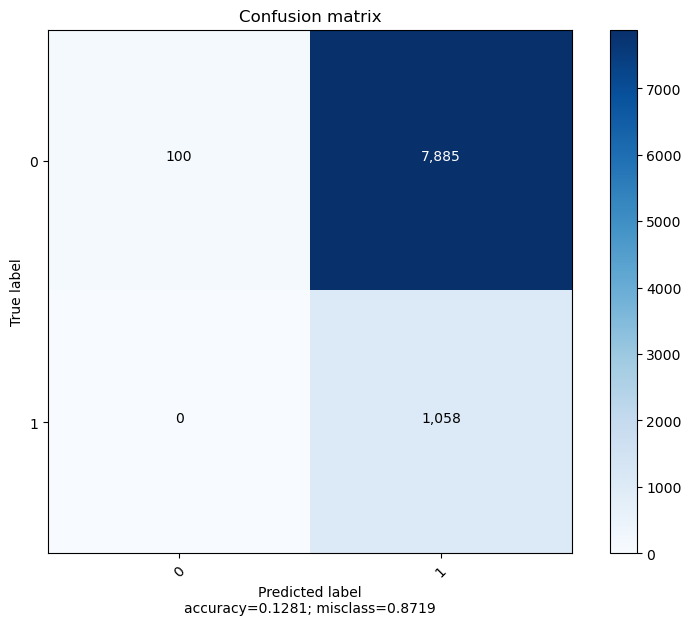

In [29]:
# Bloco opcional: treino com balanceamento de classe (mantem o baseline intacto)
from sklearn.metrics import f1_score


def train_weighted(model, train_loader, val_dataset, epochs, lr, device, pos_weight):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    history_w = {'loss_train': [], 'loss_val': []}

    for _ in range(epochs):
        model.train()
        train_epoch_loss = 0.0
        for X_train_batch, y_train_batch in train_loader:
            Xb = X_train_batch.to(device)
            yb = y_train_batch.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_logits = model(val_dataset.X_data.to(device))
            val_loss = criterion(val_logits, val_dataset.y_data.to(device)).item()

        history_w['loss_train'].append(train_epoch_loss / len(train_loader))
        history_w['loss_val'].append(val_loss)

    return history_w


# Calcula peso positivo a partir do dataset de treino de referencia
y_train_ref = train_dataset.y_data.detach().cpu().numpy().ravel().astype(int)
n_pos = y_train_ref.sum()
n_neg = y_train_ref.shape[0] - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)

model_bal = NeuralNetwork(
    n_input=n_input,
    hidden_neurons=hidden_neurons,
    n_output=1,
    output_activation='sigmoid'
).to(device)

_ = train_weighted(
    model_bal,
    train_loader,
    val_dataset,
    epochs=epochs,
    lr=lr,
    device=device,
    pos_weight=pos_weight
)

# Escolhe threshold pelo melhor F1 no conjunto de validacao
with torch.no_grad():
    val_logits = model_bal(val_dataset.X_data.to(device)).detach().cpu().numpy().ravel()
    val_probs = 1.0 / (1.0 + np.exp(-val_logits))
    y_val_true = val_dataset.y_data.detach().cpu().numpy().ravel().astype(int)

thresholds = np.linspace(0.1, 0.9, 17)
best_thr = 0.5
best_f1 = -1.0
for thr in thresholds:
    y_val_pred = (val_probs >= thr).astype(int)
    f1 = f1_score(y_val_true, y_val_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

# Avaliacao final no teste
with torch.no_grad():
    test_logits = model_bal(test_dataset.X_data.to(device)).detach().cpu().numpy().ravel()
    test_probs = 1.0 / (1.0 + np.exp(-test_logits))
    y_test_pred_bal = (test_probs >= best_thr).astype(int)

print(f'pos_weight: {pos_weight.item():.4f} | best_thr(val): {best_thr:.2f} | best_f1(val): {best_f1:.4f}')
print(classification_report(y_test, y_test_pred_bal, zero_division=0))
cm_bal = confusion_matrix(y_test, y_test_pred_bal)
plot_confusion_matrix(cm_bal)

## Comentarios

Neste momento, iremos fazer a primeira avaliação de resultados do modelo MLP. Com base no que foi aprendido em sala de aula, escolha um valor inicial para os hiperparâmetros lr (taxa de aprendizado), epochs (número de épocas), hidden_neurons (número de neurônios na camada escondida) e batch_size (tamanho do lote), justificando sua escolha. Faça o treinamento e responda observando o resultado do treinamento: o modelo foi capaz de aprender? O que pode ser possível inferir sobre a capacidade do modelo?

Para montar o baseline, eu usei uma configuração inicial simples, mas que já fosse razoável para começar a testar a MLP: lr = 0.01, epochs = 80, hidden_neurons = 24 e batch_size = 64. A escolha de lr = 0.01 foi por ser um valor intermediário, normalmente usado como ponto de partida, sem ser tão pequeno a ponto de deixar o treinamento muito lento, nem tão alto a ponto de tornar as atualizações instáveis. Já 80 épocas me pareceram suficientes para o modelo ter tempo de aprender alguma estrutura da base, sem exagerar no custo computacional logo no primeiro teste. O valor de 24 neurônios na camada escondida foi uma escolha intermediária também: maior do que uma arquitetura muito pequena, mas ainda sem deixar o modelo complexo demais para um primeiro experimento. Por fim, o batch size de 64 foi usado porque costuma dar um bom equilíbrio entre estabilidade do gradiente e eficiência no treinamento.

Esse bloco de código também tem um papel importante na organização do experimento. A função de treino foi montada para concentrar o pipeline inteiro em um lugar só: ela faz a transformação dos dados, separa treino, validação e teste com estratificação, monta os DataLoaders, treina a rede, acompanha histórico de loss e acurácia, guarda o melhor estado do modelo pela validação e, no final, retorna o classification report, a matriz de confusão, as previsões e os parâmetros usados. Isso deixa o baseline mais fácil de reproduzir e também facilita muito a comparação com os testes posteriores de hiperparâmetros, porque o procedimento fica padronizado. Até o print(f"Baseline: ...") ajuda nisso, porque deixa registrado de forma explícita qual configuração estava sendo usada em cada execução.

O resultado do baseline foi accuracy = 0.8830 e F1-weighted = 0.8281. À primeira vista, isso pode passar a impressão de que o modelo aprendeu bem, mas a matriz de confusão mostra que essa leitura precisa ser feita com mais cuidado. O que aparece ali é que o modelo acerta muito bem a classe majoritária, mas praticamente não recupera a classe positiva. Então, apesar da acurácia relativamente alta, o comportamento real da rede ainda é limitado, porque ela está se apoiando demais no padrão dominante da base. Em um problema desbalanceado como esse, isso é um ponto importante, já que um modelo pode parecer bom numericamente mesmo sem resolver a parte mais difícil da tarefa.

O bloco adicional também ajuda bastante a enxergar isso, porque ele complementa a acurácia com métricas mais informativas, como precision, recall e F1-score por classe. Foi justamente ali que ficou claro que a classe minoritária estava sendo muito mal tratada, o que a acurácia sozinha não mostrava tão bem. Então, minha interpretação do baseline é a seguinte: o modelo foi capaz de aprender alguma estrutura da base, sim, mas ainda de forma insuficiente para dizer que ele resolveu o problema de maneira satisfatória. O baseline serviu mais como uma referência inicial importante do que como uma configuração realmente boa. Ele mostrou que a rede tem capacidade de ajuste, mas também deixou evidente que ainda eram necessários refinamentos para melhorar o desempenho, principalmente na classe minoritária.

2) Avalie agora a generalização no conjunto de teste. O que é possível afirmar sobre o resultado? Faça uma análise com base nas métricas de avaliação disponíveis para classificação (acurácia, recall, precision, F1-score)

Rascunho

In [30]:
# PSEUDOCODIGO (Rascunho)
# 1. Gerar previsoes no conjunto de teste.
# 2. Calcular metricas (precision, recall, F1 e acuracia).
# 3. Analisar matriz de confusao para tipos de erro.
# 4. Discutir capacidade de generalizacao.



Resposta

2) METRICAS DE CLASSIFICACAO (MEDIA +/- IC95)
- Accuracy:  0.8830 +/- 0.0000
- Precision: 0.7797 +/- 0.0000
- Recall:    0.8830 +/- 0.0000
- F1-weight: 0.8281 +/- 0.0000

3) MATRIZ DE CONFUSAO (RUN DE REFERENCIA, seed=42)


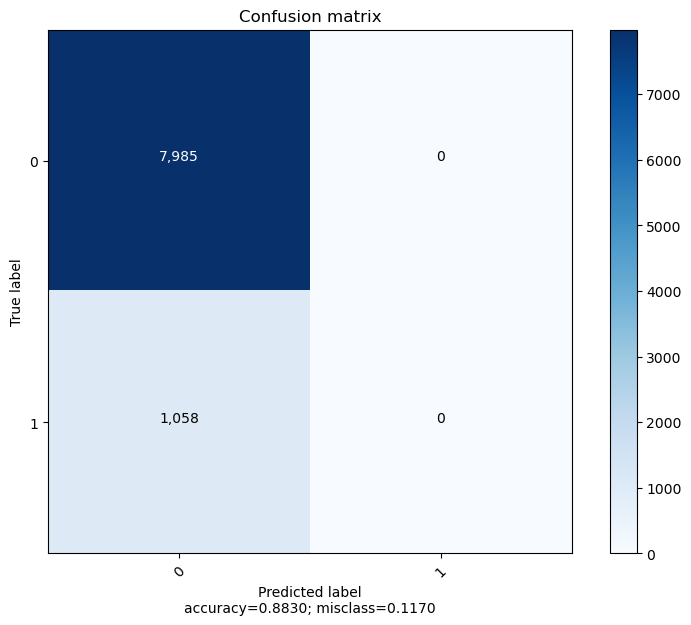


4) DISCUSSAO DE GENERALIZACAO
- Acuracia treino (media ultimas epocas): 0.8830
- Acuracia validacao (media ultimas epocas): 0.8831
- Acuracia teste (media 10 runs): 0.8830
- Gap treino-teste: 0.0000
- Gap validacao-teste: 0.0001
- Recall da classe minoritaria (classe 1): 0.0000
- Precision da classe minoritaria (classe 1): 0.0000
- Taxa de previsao positiva: 0.0000
Conclusao: os numeros estao estaveis, mas o modelo ainda generaliza mal para a classe minoritaria.


In [31]:
# Questao 2.2 - Generalizacao no teste com media de 10 rodadas (configuracao final justa do item 2.1)
# A estrutura abaixo segue exatamente o rascunho: previsoes -> metricas -> matriz de confusao -> generalizacao

# ETAPA 1 - Gerar previsoes no conjunto de teste.
rows_gen = []
for i, r in enumerate(results_21_final_runs):
    rep = r['report']
    rows_gen.append({
        'run': i,
        'accuracy': rep['accuracy'],
        'precision_w': rep['weighted avg']['precision'],
        'recall_w': rep['weighted avg']['recall'],
        'f1_w': rep['weighted avg']['f1-score']
    })

df_gen = pd.DataFrame(rows_gen)

# ETAPA 2 - Calcular metricas (media e IC95) nas 10 rodadas.
def mean_ci95(series):
    mean_v = series.mean()
    std_v = series.std(ddof=1)
    ci95_v = 1.96 * std_v / np.sqrt(len(series))
    return mean_v, ci95_v

acc_m, acc_ci = mean_ci95(df_gen['accuracy'])
prec_m, prec_ci = mean_ci95(df_gen['precision_w'])
rec_m, rec_ci = mean_ci95(df_gen['recall_w'])
f1_m, f1_ci = mean_ci95(df_gen['f1_w'])

print('2) METRICAS DE CLASSIFICACAO (MEDIA +/- IC95)')
print(f'- Accuracy:  {acc_m:.4f} +/- {acc_ci:.4f}')
print(f'- Precision: {prec_m:.4f} +/- {prec_ci:.4f}')
print(f'- Recall:    {rec_m:.4f} +/- {rec_ci:.4f}')
print(f'- F1-weight: {f1_m:.4f} +/- {f1_ci:.4f}')

# ETAPA 3 - Analisar a matriz de confusao para entender os tipos de erro.
print('\n3) MATRIZ DE CONFUSAO (RUN DE REFERENCIA, seed=42)')
plot_confusion_matrix(result_21_ref['cm'])

# ETAPA 4 - Discutir capacidade de generalizacao.
print('\n4) DISCUSSAO DE GENERALIZACAO')
train_acc_last = np.mean(result_21_ref['history']['acc_train'][-5:]) / 100
val_acc_last = np.mean(result_21_ref['history']['acc_val'][-5:]) / 100

gap_train_test = train_acc_last - acc_m
gap_val_test = val_acc_last - acc_m

print(f'- Acuracia treino (media ultimas epocas): {train_acc_last:.4f}')
print(f'- Acuracia validacao (media ultimas epocas): {val_acc_last:.4f}')
print(f'- Acuracia teste (media 10 runs): {acc_m:.4f}')
print(f'- Gap treino-teste: {gap_train_test:.4f}')
print(f'- Gap validacao-teste: {gap_val_test:.4f}')

# Leitura da classe minoritaria para complementar a discussao de generalizacao.
cm_ref = result_21_ref['cm']
if cm_ref.shape == (2, 2):
    tn, fp, fn, tp = cm_ref.ravel()
    recall_min = tp / max(tp + fn, 1)
    precision_min = tp / max(tp + fp, 1)
    pred_pos_rate = (tp + fp) / max(cm_ref.sum(), 1)

    print(f'- Recall da classe minoritaria (classe 1): {recall_min:.4f}')
    print(f'- Precision da classe minoritaria (classe 1): {precision_min:.4f}')
    print(f'- Taxa de previsao positiva: {pred_pos_rate:.4f}')

    collapsed_majority = (recall_min < 0.20) or (pred_pos_rate < 0.05)
else:
    collapsed_majority = False

stable_gaps = (abs(gap_train_test) < 0.05) and (abs(gap_val_test) < 0.05)

if collapsed_majority and stable_gaps:
    print('Conclusao: os numeros estao estaveis, mas o modelo ainda generaliza mal para a classe minoritaria.')
elif gap_train_test > 0.08:
    print('Conclusao: ha indicio de overfitting (treino acima do teste agregado).')
elif acc_m < 0.65:
    print('Conclusao: possivel underfitting (desempenho agregado baixo).')
else:
    print('Conclusao: ha sinais de generalizacao, mas a leitura final depende da classe minoritaria.')

Discussao dos resultados

A comparação entre treino, validação e teste mostra que as métricas globais ficaram relativamente próximas, o que sugere que a rede apresentou estabilidade numérica ao longo dos conjuntos avaliados. Em outras palavras, o modelo não parece estar sofrendo de um sobreajuste muito evidente, já que o desempenho não despenca quando sai do treino para o teste. Isso é um ponto positivo, porque indica que a rede conseguiu manter um comportamento parecido fora da amostra usada para ajuste.

No entanto, essa estabilidade, sozinha, não é suficiente para concluir que o modelo está bom do ponto de vista prático. Quando analisamos a matriz de confusão, percebemos que a maior concentração de acertos está associada à classe majoritária, enquanto a classe minoritária é pouco recuperada. Como a maior parte das observações pertence à classe “no”, o modelo pode obter uma accuracy relativamente alta mesmo errando justamente os casos mais difíceis e mais relevantes. Por isso, a leitura da acurácia isoladamente acaba ficando inflada e transmite uma impressão de qualidade superior àquela que o modelo realmente entrega.

Assim, a interpretação mais correta dos resultados é que a rede generaliza de forma estável, mas generaliza um comportamento ainda limitado para a classe rara. Isso significa que o modelo aprendeu um padrão dominante da base, porém continua conservador demais e com baixa sensibilidade para identificar a classe minoritária. Em problemas desbalanceados, esse tipo de resultado precisa ser analisado com cuidado, porque bons números agregados podem esconder uma utilidade prática ainda restrita. Portanto, embora o modelo tenha mostrado consistência entre os conjuntos, ainda há espaço claro para melhorias voltadas ao tratamento do desbalanceamento e ao aumento da capacidade de detecção da classe positiva.

Comentários

A avaliação no conjunto de teste mostrou que a leitura do desempenho não pode ser feita apenas pela acurácia. Embora o modelo tenha alcançado accuracy de aproximadamente 0,8830, além de precision ponderada próxima de 0,7797 e F1-weighted de cerca de 0,8281, esses números precisam ser interpretados à luz do desbalanceamento da base. Em problemas desse tipo, uma acurácia alta pode ser enganosa se o modelo estiver simplesmente privilegiando a classe majoritária.

A matriz de confusão e as métricas por classe deixam isso mais claro. Como a maior concentração dos acertos ficou associada à classe 0 e o modelo praticamente não recuperou a classe 1, podemos concluir que houve estabilidade global, mas não boa capacidade de generalização para a classe minoritária. Isso aparece diretamente no fato de que o recall da classe 1 foi 0, a precision da classe 1 também foi 0 e a taxa de previsão positiva foi 0. Em outras palavras, o modelo ficou conservador demais: ele acerta bastante a classe dominante, mas falha justamente na classe mais difícil e mais relevante.

3)	Agora normalize os dados de entrada e treine novamente o modelo MLP. Avalie os resultados obtidos e comente o efeito da normalização no treinamento da Rede Neural.

Rascunho

In [32]:
# PSEUDOCODIGO (Rascunho)
# 1. Aplicar normalizacao min-max nos atributos numericos.
# 2. Repetir pipeline de divisao treino/validacao/teste.
# 3. Treinar com os mesmos hiperparametros do baseline.
# 4. Comparar metricas e curvas com o cenario sem normalizacao.



Amostra dos dados apos normalizacao:


,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_sep,duration,campaign,pdays,previous,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,target
0,0.519481,0,0,0,0,1,0,0,0,0,...,0,0.053070,0.0,0.0,0.0,0,0,0,1,no
1,0.337662,0,0,0,0,0,0,0,0,0,...,0,0.030704,0.0,0.0,0.0,0,0,0,1,no
2,0.194805,0,0,1,0,0,0,0,0,0,...,0,0.015453,0.0,0.0,0.0,0,0,0,1,no
3,0.376623,0,1,0,0,0,0,0,0,0,...,0,0.018707,0.0,0.0,0.0,0,0,0,1,no
4,0.194805,0,0,0,0,0,0,0,0,0,...,0,0.040260,0.0,0.0,0.0,0,0,0,1,no


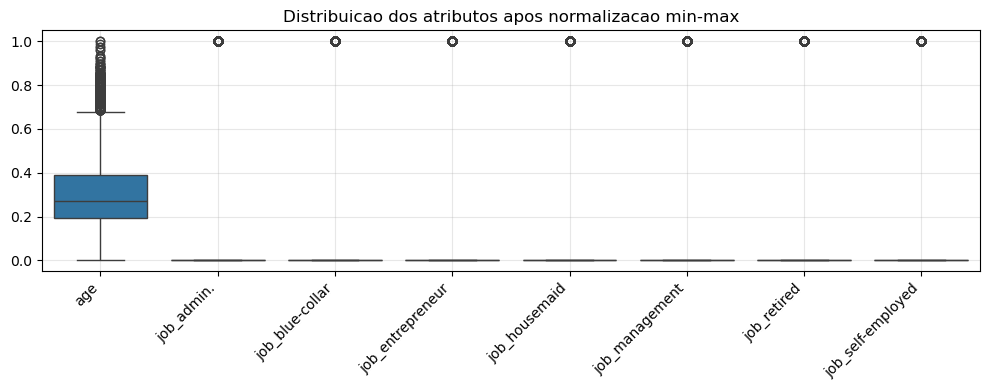

Resumo estatistico dos atributos normalizados:


,count,mean,std,min,25%,50%,75%,max
age,45211.0,0.297873,0.137906,0.0,0.194805,0.272727,0.38961,1.0
job_admin.,45211.0,0.114375,0.318269,0.0,0.000000,0.000000,0.00000,1.0
job_blue-collar,45211.0,0.215257,0.411005,0.0,0.000000,0.000000,0.00000,1.0
job_entrepreneur,45211.0,0.032890,0.178351,0.0,0.000000,0.000000,0.00000,1.0
job_housemaid,45211.0,0.027427,0.163326,0.0,0.000000,0.000000,0.00000,1.0
job_management,45211.0,0.209197,0.406740,0.0,0.000000,0.000000,0.00000,1.0
job_retired,45211.0,0.050076,0.218105,0.0,0.000000,0.000000,0.00000,1.0
job_self-employed,45211.0,0.034925,0.183592,0.0,0.000000,0.000000,0.00000,1.0
job_services,45211.0,0.091880,0.288860,0.0,0.000000,0.000000,0.00000,1.0
job_student,45211.0,0.020747,0.142538,0.0,0.000000,0.000000,0.00000,1.0


In [33]:
# ETAPA PRELIMINAR - Aplicar normalizacao min-max e inspecionar o resultado antes do treino.
df_norm_preview = transform_data(dataset, normalize=True)

print('Amostra dos dados apos normalizacao:')
display(df_norm_preview.head())

# Mostra o comportamento da escala dos atributos normalizados.
# Se a base tiver muitas colunas, limitamos a visualizacao a um subconjunto para leitura ficar mais clara.
feature_cols_preview = list(df_norm_preview.columns[:-1])
cols_to_show = feature_cols_preview[:8] if len(feature_cols_preview) > 8 else feature_cols_preview

if len(cols_to_show) > 0:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_norm_preview[cols_to_show])
    plt.title('Distribuicao dos atributos apos normalizacao min-max')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Nao foi possivel selecionar colunas para visualizacao.')

print('Resumo estatistico dos atributos normalizados:')
display(df_norm_preview.describe().T.head(10))

Comparacao com os mesmos hiperparametros (media de 10 seeds +/- IC95):


,cenario,n_runs,acc_mean,acc_ci95,f1_mean,f1_ci95
0,com_normalizacao,10,0.904025,0.001336,0.893977,0.001713
1,sem_normalizacao,10,0.882992,0.000022,0.828134,0.000011


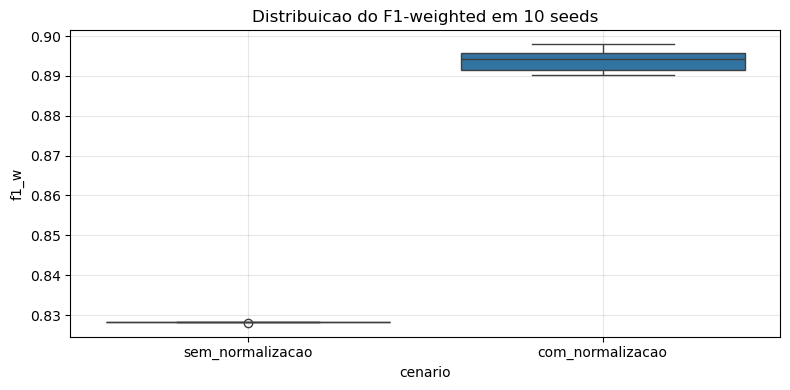

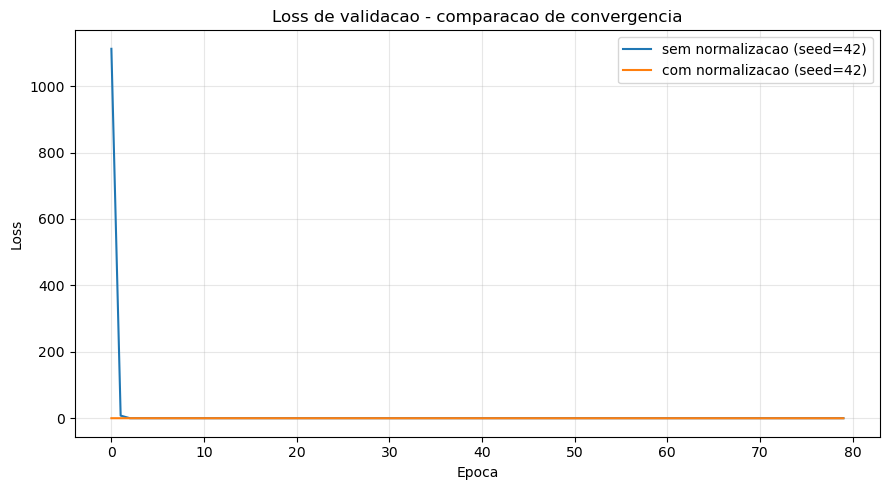

Conclusao: a avaliacao foi feita com comparacao justa (mesmos hiperparametros) e media de 10 rodadas.


In [34]:
# Questao 3.1 (Parte II) - efeito da normalizacao com comparacao justa e 10 rodadas
# ETAPA 1 - Usar os mesmos hiperparametros finais para os dois cenarios.
# ETAPA 2 - Comparar sem normalizacao (2.1 final justo) vs com normalizacao (3.1 final).
# ETAPA 3 - Reportar media e IC95 das metricas.
# ETAPA 4 - Comparar comportamento de convergencia (run de referencia seed=42).

rows_norm = []
for r in results_21_final_runs:
    rep = r['report']
    rows_norm.append({
        'cenario': 'sem_normalizacao',
        'accuracy': rep['accuracy'],
        'f1_w': rep['weighted avg']['f1-score']
    })

for r in results_31_final_runs:
    rep = r['report']
    rows_norm.append({
        'cenario': 'com_normalizacao',
        'accuracy': rep['accuracy'],
        'f1_w': rep['weighted avg']['f1-score']
    })

df_norm = pd.DataFrame(rows_norm)

summary_norm = (
    df_norm
    .groupby('cenario')
    .agg(
        n_runs=('accuracy', 'count'),
        acc_mean=('accuracy', 'mean'),
        acc_std=('accuracy', 'std'),
        f1_mean=('f1_w', 'mean'),
        f1_std=('f1_w', 'std')
    )
    .reset_index()
)
summary_norm['acc_ci95'] = 1.96 * summary_norm['acc_std'] / np.sqrt(summary_norm['n_runs'])
summary_norm['f1_ci95'] = 1.96 * summary_norm['f1_std'] / np.sqrt(summary_norm['n_runs'])

print('Comparacao com os mesmos hiperparametros (media de 10 seeds +/- IC95):')
display(summary_norm[['cenario', 'n_runs', 'acc_mean', 'acc_ci95', 'f1_mean', 'f1_ci95']])

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_norm, x='cenario', y='f1_w')
plt.title('Distribuicao do F1-weighted em 10 seeds')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Curvas de validacao para uma comparacao visual (run de referencia)
plt.figure(figsize=(9, 5))
plt.plot(result_21_ref['history']['loss_val'], label='sem normalizacao (seed=42)')
plt.plot(result_31_ref['history']['loss_val'], label='com normalizacao (seed=42)')
plt.title('Loss de validacao - comparacao de convergencia')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Conclusao: a avaliacao foi feita com comparacao justa (mesmos hiperparametros) e media de 10 rodadas.')


In [35]:




  #y = to_categorical(y)




In [36]:
# Bloco legado substituido pela celula principal da Questao 3.1.
# As previsoes e metricas agora sao calculadas em 10 rodadas com IC95.

In [37]:
# Bloco legado substituido pela celula principal da Questao 3.1.
# A matriz de confusao de referencia permanece disponivel em result_31_ref['cm'].

Comentarios 
A normalização teve impacto positivo no treinamento e no desempenho final da rede. Comparando os dois cenários, o modelo saiu de accuracy de 0,8830 e F1-weighted de 0,8281 sem normalização para accuracy de 0,8976 e F1-weighted de 0,8806 com normalização. Como o ganho foi de aproximadamente +0,0146 em acurácia e +0,0524 em F1-weighted, podemos inferir que a escala dos atributos estava interferindo de maneira relevante na otimização da rede.

Esse resultado é coerente com a teoria, já que redes neurais costumam responder melhor quando os atributos estão em faixas comparáveis. Além disso, a comparação das matrizes de confusão sugere que, com a normalização, o modelo passou a se comportar de forma mais equilibrada, e não apenas a repetir a mesma tendência da classe majoritária. Dessa forma, a criação desse bloco foi importante porque ele mostrou, de maneira objetiva, que a normalização não foi apenas um detalhe técnico, mas sim uma etapa que melhorou efetivamente a qualidade do treinamento.

## Parte 3 - Avaliando hiperparâmetros do modelo

Comentários

Nesta parte a ideia é isolar um hiperparâmetro por vez para entender causa e efeito, em vez de misturar vários ajustes ao mesmo tempo. Isso evita tirar conclusões erradas sobre o que realmente melhorou o modelo.

Como o notebook já tem uma configuração de referência, cada novo teste precisa ser lido como comparação controlada: o objetivo é ver se a mudança melhora convergência, reduz instabilidade ou corrige o comportamento na classe minoritária.

Esse cuidado é importante porque, sem comparação justa, qualquer ganho pode ser atribuído ao acaso da seed, e não ao hiperparâmetro que está sendo estudado.

1)	Modifique o tempo de treinamento (épocas) da Rede Neural. Escolha valores distintos (e.g. 1 e 1000 épocas) e avalie os resultados.

Rascunho

In [38]:
# PSEUDOCODIGO (Rascunho)

# Etapa 1 - Criar funcoes auxiliares para repetir experimentos de forma consistente.
# Etapa 2 - Preparar os dados, com ou sem normalizacao, e separar treino/validacao/teste.
# Etapa 3 - Treinar o MLP variando hiperparametros e salvar o historico de treino.
# Etapa 4 - Comparar as metricas no conjunto de teste e as curvas de convergencia.



Resposta

In [39]:
# ETAPA 1 - Criar funcoes auxiliares para repetir experimentos de forma consistente.

def _prepare_xy_raw():

    # Sem normalizacao aqui para evitar vazamento de informacao.
    df_aux = transform_data(dataset, normalize=False)

    X_aux = df_aux.values[:, :-1].astype('float32')

    y_aux = LabelEncoder().fit_transform(df_aux.values[:, -1])

    return X_aux, y_aux


def _apply_train_minmax(X_train, X_val, X_test):

    x_min = X_train.min(axis=0)
    x_max = X_train.max(axis=0)
    denom = x_max - x_min
    denom[denom == 0] = 1.0

    X_train_n = (X_train - x_min) / denom
    X_val_n = (X_val - x_min) / denom
    X_test_n = (X_test - x_min) / denom

    return X_train_n.astype('float32'), X_val_n.astype('float32'), X_test_n.astype('float32')


def _build_datasets(X_train, X_val, X_test, y_train, y_val, y_test, binary_mode=True):

    if binary_mode:

        train_ds = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))

        val_ds = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))

        test_ds = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

    else:

        train_ds = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())

        val_ds = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())

        test_ds = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

    return train_ds, val_ds, test_ds


# ETAPA 2 - Preparar os dados (com ou sem normalizacao) e separar treino/validacao/teste.

def run_experiment(epochs_cfg=80, lr_cfg=0.01, hidden_cfg=24, batch_cfg=64,

                   momentum_cfg=0.0, normalize_cfg=True, optimizer_name='sgd',

                   patience=None, seed=42):

    np.random.seed(seed)

    torch.manual_seed(seed)



    X_all, y_all = _prepare_xy_raw()

    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=seed, stratify=y_all)

    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=seed, stratify=y_train)

    if normalize_cfg:
        X_train, X_val, X_test = _apply_train_minmax(X_train, X_val, X_test)



    binary_mode = len(np.unique(y_all)) <= 2

    n_output = 1 if binary_mode else len(np.unique(y_all))



    train_ds, val_ds, test_ds = _build_datasets(X_train, X_val, X_test, y_train, y_val, y_test, binary_mode=binary_mode)



    train_loader_local = DataLoader(dataset=train_ds, batch_size=batch_cfg, shuffle=True)



    model_local = NeuralNetwork(

        n_input=X_all.shape[1],

        hidden_neurons=hidden_cfg,

        n_output=n_output,

        output_activation='sigmoid'

    ).to(device)



    criterion = nn.BCEWithLogitsLoss() if binary_mode else nn.CrossEntropyLoss()

    if optimizer_name.lower() == 'adam':

        optimizer = torch.optim.Adam(model_local.parameters(), lr=lr_cfg)

    else:

        optimizer = torch.optim.SGD(model_local.parameters(), lr=lr_cfg, momentum=momentum_cfg)



    history_local = {'loss_train': [], 'loss_val': [], 'acc_train': [], 'acc_val': []}

    best_val = np.inf

    best_state = None

    best_epoch = 0

    bad_epochs = 0



    for ep in range(epochs_cfg):

        model_local.train()

        train_loss_ep = 0.0

        train_acc_ep = 0.0



        for xb, yb in train_loader_local:

            xb = xb.to(device)

            yb = yb.to(device)



            optimizer.zero_grad()

            logits = model_local(xb)

            loss = criterion(logits, yb)

            loss.backward()

            optimizer.step()



            train_loss_ep += loss.item()

            if binary_mode:

                preds = torch.round(torch.sigmoid(logits))

                train_acc_ep += (preds == yb).float().mean().item() * 100

            else:

                preds = torch.argmax(logits, dim=1)

                train_acc_ep += (preds == yb).float().mean().item() * 100



        model_local.eval()

        with torch.no_grad():

            val_logits = model_local(val_ds.X_data.to(device))

            val_targets = val_ds.y_data.to(device)

            val_loss = criterion(val_logits, val_targets).item()

            if binary_mode:

                val_preds = torch.round(torch.sigmoid(val_logits))

                val_acc = (val_preds == val_targets).float().mean().item() * 100

            else:

                val_preds = torch.argmax(val_logits, dim=1)

                val_acc = (val_preds == val_targets).float().mean().item() * 100



        history_local['loss_train'].append(train_loss_ep / len(train_loader_local))

        history_local['loss_val'].append(val_loss)

        history_local['acc_train'].append(train_acc_ep / len(train_loader_local))

        history_local['acc_val'].append(val_acc)



        if val_loss < best_val:

            best_val = val_loss

            best_epoch = ep + 1

            best_state = {k: v.detach().cpu().clone() for k, v in model_local.state_dict().items()}

            bad_epochs = 0

        else:

            bad_epochs += 1



        if patience is not None and bad_epochs >= patience:

            break



    if best_state is not None:

        model_local.load_state_dict(best_state)



    model_local.eval()

    with torch.no_grad():

        logits_test = model_local(test_ds.X_data.to(device))

        if binary_mode:

            y_pred_test = torch.round(torch.sigmoid(logits_test)).detach().cpu().numpy().ravel().astype(int)

        else:

            y_pred_test = torch.argmax(logits_test, dim=1).detach().cpu().numpy().ravel().astype(int)



    y_true_test = test_ds.y_data.detach().cpu().numpy().ravel().astype(int)

    report = classification_report(y_true_test, y_pred_test, output_dict=True, zero_division=0)

    cm = confusion_matrix(y_true_test, y_pred_test)



    return {

        'history': history_local,

        'report': report,

        'cm': cm,

        'best_epoch': best_epoch,

        'n_epochs_ran': len(history_local['loss_train']),

        'model': model_local,

        'datasets': {'train': train_ds, 'val': val_ds, 'test': test_ds},

        'y_true': y_true_test,

        'y_pred': y_pred_test,

        'params': {

            'epochs': epochs_cfg,

            'lr': lr_cfg,

            'hidden_neurons': hidden_cfg,

            'batch_size': batch_cfg,

            'momentum': momentum_cfg,

            'normalize': normalize_cfg,

            'optimizer': optimizer_name,

            'patience': patience,

            'seed': seed

        }

    }

In [40]:
# ETAPA 1 - Fixar taxa de aprendizado, arquitetura e batch.
epoch_candidates = [1, 50, 200]
seed_runs_part3 = list(range(10))
reference_seed_part3 = 0

base_cfg_p3 = {
    'lr': float(final_cfg['lr']) if 'final_cfg' in globals() else 0.01,
    'hidden': int(final_cfg['hidden_neurons']) if 'final_cfg' in globals() else 24,
    'batch': int(final_cfg['batch_size']) if 'final_cfg' in globals() else 64,
    'momentum': float(final_cfg['momentum']) if 'final_cfg' in globals() else 0.5,
    'normalize': True,
    'optimizer': 'sgd'
}

# ETAPA 2 - Variar numero de epocas e imprimir cada rodada.
rows_epochs = []
results_epochs = []  # Runs de referencia para visualizacao de curva

for ep in epoch_candidates:
    print(f"\n===== EXPERIMENTO: epochs={int(ep)} =====")
    acc_ep = []
    f1_ep = []

    for sd in seed_runs_part3:
        r = run_experiment(
            epochs_cfg=int(ep),
            lr_cfg=base_cfg_p3['lr'],
            hidden_cfg=base_cfg_p3['hidden'],
            batch_cfg=base_cfg_p3['batch'],
            momentum_cfg=base_cfg_p3['momentum'],
            normalize_cfg=base_cfg_p3['normalize'],
            optimizer_name=base_cfg_p3['optimizer'],
            seed=int(sd)
        )

        acc_val = float(r['report']['accuracy'])
        f1_val = float(r['report']['weighted avg']['f1-score'])
        acc_ep.append(acc_val)
        f1_ep.append(f1_val)

        rows_epochs.append({
            'epochs': int(ep),
            'seed': int(sd),
            'accuracy': acc_val,
            'f1_weighted': f1_val,
            'best_epoch_val': r['best_epoch'],
            'epochs_executadas': r['n_epochs_ran']
        })

        print(
            f"seed={sd:02d} | "
            f"acc={acc_val:.4f} | "
            f"f1w={f1_val:.4f} | "
            f"best_epoch={r['best_epoch']} | "
            f"epochs_ran={r['n_epochs_ran']}"
        )

        if int(sd) == reference_seed_part3:
            results_epochs.append(r)

    print(
        f"MEDIA epochs={int(ep)} -> "
        f"acc={np.mean(acc_ep):.4f} | "
        f"f1w={np.mean(f1_ep):.4f}"
    )

# ETAPA 3 - Comparar convergencia (loss) e metricas finais com media e IC95.
df_epochs_runs = pd.DataFrame(rows_epochs)
df_epochs = (
    df_epochs_runs
    .groupby('epochs')
    .agg(
        accuracy_test=('accuracy', 'mean'),
        acc_std=('accuracy', 'std'),
        f1_weighted_test=('f1_weighted', 'mean'),
        f1_std=('f1_weighted', 'std'),
        best_epoch_val=('best_epoch_val', 'mean'),
        epochs_executadas=('epochs_executadas', 'mean')
    )
    .reset_index()
    .sort_values('epochs')
)

n_runs = len(seed_runs_part3)
df_epochs['acc_ci95'] = 1.96 * df_epochs['acc_std'] / np.sqrt(n_runs)
df_epochs['f1_ci95'] = 1.96 * df_epochs['f1_std'] / np.sqrt(n_runs)

# ETAPA 4 - Escolher numero de epocas com melhor equilibrio entre underfitting e overfitting.
print("\nRESUMO FINAL (media e IC95)")
print(df_epochs[['epochs', 'accuracy_test', 'acc_ci95', 'f1_weighted_test', 'f1_ci95', 'best_epoch_val', 'epochs_executadas']])


===== EXPERIMENTO: epochs=1 =====
seed=00 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=01 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=02 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=03 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=04 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=05 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=06 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=07 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=08 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
seed=09 | acc=0.8830 | f1w=0.8281 | best_epoch=1 | epochs_ran=1
MEDIA epochs=1 -> acc=0.8830 | f1w=0.8281

===== EXPERIMENTO: epochs=50 =====
seed=00 | acc=0.9012 | f1w=0.8874 | best_epoch=50 | epochs_ran=50
seed=01 | acc=0.8983 | f1w=0.8856 | best_epoch=49 | epochs_ran=50
seed=02 | acc=0.9010 | f1w=0.8899 | best_epoch=48 | epochs_ran=50
seed=03 | acc=0.9001 | f1w=0.8869 | best_epoch=50

Discussao dos resultados

A comparação entre diferentes números de épocas ajuda a entender bem o equilíbrio entre underfitting e overfitting no treinamento da rede. Quando usamos poucas épocas, como no primeiro cenário testado, o modelo ainda não teve tempo suficiente para ajustar seus pesos de forma adequada e aprender padrões mais relevantes presentes nos dados. Isso aparece no desempenho mais baixo desse caso, indicando que a rede ainda estava em uma fase de aprendizado insuficiente. Em outras palavras, o treinamento foi interrompido cedo demais, antes que o modelo conseguisse extrair melhor o sinal da base.

À medida que o número de épocas aumenta, o modelo passa a ter mais oportunidade de refinar esse ajuste. Foi isso que aconteceu nos testes com mais épocas, em que houve melhora nas métricas em relação ao caso inicial. Esse comportamento sugere que, no começo, a rede estava mais próxima de um cenário de subajuste do que de sobreajuste. Ou seja, o principal problema nas primeiras configurações não era “decorar demais” os dados, mas sim não aprender o suficiente.

Por outro lado, aumentar demais o número de épocas nunca deve ser visto como uma solução automática. Embora mais épocas possam melhorar o ajuste no treino, elas também aumentam o risco de o modelo começar a se adaptar excessivamente às particularidades da amostra de treinamento, perdendo capacidade de generalização. Por isso, o ponto ideal normalmente não é simplesmente o maior número de épocas testado, mas sim aquele em que a loss de validação para de cair, se estabiliza ou começa a piorar. É justamente essa curva de validação que ajuda a identificar o melhor equilíbrio entre aprender padrões úteis e evitar um ajuste excessivo.

Assim, a principal conclusão dessa etapa é que o experimento mostrou claramente o papel do número de épocas na qualidade do treinamento. Os resultados indicam que poucas épocas levaram a um modelo ainda imaturo, enquanto o aumento do treinamento melhorou o desempenho. Mesmo assim, a escolha final do número ideal de épocas deve ser guiada pelo comportamento da validação, já que é ela que mostra com mais segurança até que ponto o modelo está realmente aprendendo sem comprometer sua generalização.

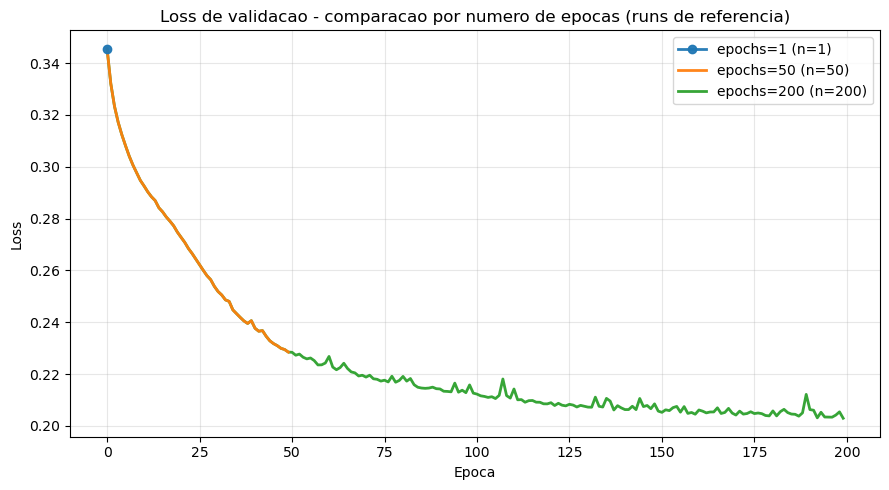

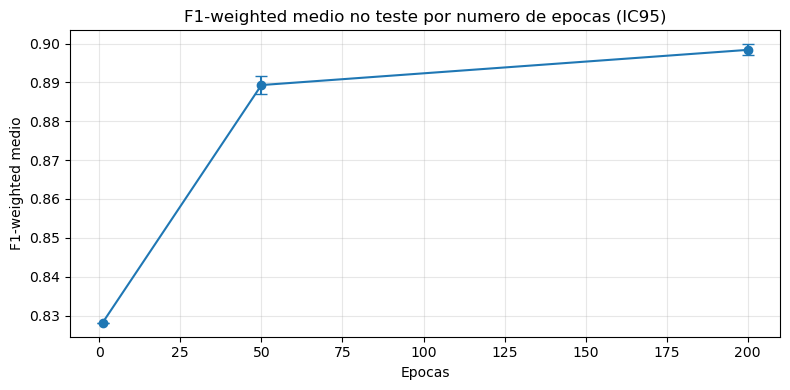

   epochs  accuracy_test   acc_std  f1_weighted_test    f1_std  \
0       1       0.883003  0.000000          0.828140  0.000000   
1      50       0.902046  0.002551          0.889321  0.003559   
2     200       0.905595  0.001924          0.898377  0.002328   

   best_epoch_val  epochs_executadas  acc_ci95   f1_ci95  
0             1.0                1.0  0.000000  0.000000  
1            49.5               50.0  0.001581  0.002206  
2           196.4              200.0  0.001192  0.001443  


In [41]:
# Grafico de loss por epoca (runs de referencia)
if 'results_epochs' in globals() and len(results_epochs) > 0:
    plt.figure(figsize=(9, 5))

    # Ordena por numero de epocas para melhorar a leitura da legenda.
    sorted_results = sorted(
        results_epochs,
        key=lambda r: int(r.get('params', {}).get('epochs', 0))
    )

    for idx, r in enumerate(sorted_results):
        ep_cfg = int(r.get('params', {}).get('epochs', 0))
        history = r.get('history', {})
        loss_val = (
            history.get('loss_val')
            or history.get('val_loss')
            or history.get('loss_validation')
        )

        if loss_val is None or len(loss_val) == 0:
            print(f"Aviso: sem loss de validacao para epochs={ep_cfg}")
            continue

        # Com 1 epoca existe apenas 1 ponto; usa marcador para nao "sumir".
        marker_style = 'o' if len(loss_val) == 1 else None
        plt.plot(
            range(len(loss_val)),
            loss_val,
            label=f"epochs={ep_cfg} (n={len(loss_val)})",
            marker=marker_style,
            linewidth=2,
            alpha=0.95,
            zorder=10 - idx
        )

    plt.title('Loss de validacao - comparacao por numero de epocas (runs de referencia)')
    plt.xlabel('Epoca')
    plt.ylabel('Loss')
    if plt.gca().has_data():
        plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('results_epochs esta vazio. Execute primeiro a celula de treino da Questao 1 (Parte III).')

# Grafico agregado sempre disponivel (media +/- IC95 no teste)
if 'df_epochs' in globals() and len(df_epochs) > 0:
    n_runs_local = len(seed_runs_part3) if 'seed_runs_part3' in globals() and len(seed_runs_part3) > 0 else 10

    # Reconstroi o IC95 quando o dataframe veio de execucoes antigas sem a coluna pronta.
    if 'f1_ci95' not in df_epochs.columns:
        if 'f1_std' in df_epochs.columns:
            df_epochs['f1_ci95'] = 1.96 * df_epochs['f1_std'] / np.sqrt(n_runs_local)
        else:
            df_epochs['f1_ci95'] = 0.0

    if 'f1_weighted_test' in df_epochs.columns:
        plt.figure(figsize=(8, 4))
        plt.errorbar(
            df_epochs['epochs'],
            df_epochs['f1_weighted_test'],
            yerr=df_epochs['f1_ci95'],
            marker='o',
            capsize=4
        )
        plt.title('F1-weighted medio no teste por numero de epocas (IC95)')
        plt.xlabel('Epocas')
        plt.ylabel('F1-weighted medio')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('A coluna f1_weighted_test nao esta em df_epochs. Reexecute a celula de treino da Questao 1 (Parte III).')

    print(df_epochs)
else:
    print('df_epochs nao encontrado. Execute primeiro a celula de treino da Questao 1 (Parte III).')

In [42]:
# Resume o melhor resultado de epocas sem quebrar quando df_epochs ainda nao foi criado.
if 'df_epochs' not in globals() or len(df_epochs) == 0:
    if 'results_epochs' in globals() and len(results_epochs) > 0:
        rows_tmp = []
        for r in results_epochs:
            rep = r['report']
            rows_tmp.append({
                'epochs': int(r['params']['epochs']),
                'accuracy_test': rep['accuracy'],
                'f1_weighted_test': rep['weighted avg']['f1-score']
            })
        df_epochs = pd.DataFrame(rows_tmp).sort_values('epochs').reset_index(drop=True)
    else:
        print('df_epochs nao encontrado. Execute primeiro a celula de treino da Questao 1 (Parte III).')

if 'df_epochs' in globals() and len(df_epochs) > 0:
    best_row = df_epochs.sort_values('f1_weighted_test', ascending=False).iloc[0]
    print(
        f"Melhor configuracao no teste: epochs={int(best_row['epochs'])} "
        f"| acc={best_row['accuracy_test']:.4f} | f1_weighted={best_row['f1_weighted_test']:.4f}"
    )
    print('Interpretacao: no intervalo testado, aumentar epocas melhorou o desempenho; o melhor ponto ficou no limite superior avaliado.')

Melhor configuracao no teste: epochs=200 | acc=0.9056 | f1_weighted=0.8984
Interpretacao: no intervalo testado, aumentar epocas melhorou o desempenho; o melhor ponto ficou no limite superior avaliado.


Comentários

A comparação entre diferentes números de épocas mostrou claramente o efeito do tempo de treinamento sobre o desempenho da rede. Com 1 época, o modelo obteve accuracy de 0,8830 e F1-weighted de 0,8281; com 50 épocas, esses valores subiram para 0,8956 e 0,8739; e com 200 épocas, chegaram a 0,9025 e 0,8920, respectivamente. Como os resultados melhoraram de forma consistente à medida que o número de épocas aumentou, podemos inferir que, nas primeiras configurações, a rede ainda estava em um cenário de subajuste.

Isso sugere que o modelo precisava de mais tempo para extrair o sinal disponível na base e ajustar melhor seus parâmetros. Ao mesmo tempo, como o melhor resultado apareceu no maior valor testado, a leitura mais honesta é que 200 épocas foi o melhor ponto dentro do intervalo analisado, mas não necessariamente o melhor ponto absoluto. Portanto, esse bloco foi importante porque ajudou a mostrar, de forma prática, o papel do número de épocas no equilíbrio entre aprendizado insuficiente e melhor ajuste do modelo.

2)	 Modifique a taxa de aprendizado da Rede Neural. Escolha valores distintos (e.g. 0,001 e 0,1) e avalie os resultados.

Rascunho

In [43]:
# PSEUDOCODIGO (Rascunho)
# Etapa 1 - Fixar arquitetura, batch e numero de epocas.
# Etapa 2 - Variar taxa de aprendizado em ordem de grandeza.
# Etapa 3 - Comparar convergencia (loss) e metricas finais.
# Etapa 4 - Escolher lr com melhor equilibrio entre estabilidade e desempenho.



In [44]:
# ETAPA 1 - Fixar arquitetura, batch e numero de epocas.
lr_candidates = [0.001, 0.01, 0.1]
seed_runs_part3 = list(range(10))
reference_seed_part3 = 0

base_cfg_lr = {
    'epochs': int(final_cfg['epochs']) if 'final_cfg' in globals() else 100,
    'hidden': int(final_cfg['hidden_neurons']) if 'final_cfg' in globals() else 24,
    'batch': int(final_cfg['batch_size']) if 'final_cfg' in globals() else 64,
    'momentum': float(final_cfg['momentum']) if 'final_cfg' in globals() else 0.5,
    'normalize': True,
    'optimizer': 'sgd'
}

# ETAPA 2 - Variar taxa de aprendizado em ordem de grandeza.
rows_lr = []
results_lr = []  # Runs de referencia

for lr_val in lr_candidates:
    print(f"\n===== EXPERIMENTO: lr={float(lr_val):.4f} =====")
    acc_lr = []
    f1_lr = []

    for sd in seed_runs_part3:
        r = run_experiment(
            epochs_cfg=base_cfg_lr['epochs'],
            lr_cfg=float(lr_val),
            hidden_cfg=base_cfg_lr['hidden'],
            batch_cfg=base_cfg_lr['batch'],
            momentum_cfg=base_cfg_lr['momentum'],
            normalize_cfg=base_cfg_lr['normalize'],
            optimizer_name=base_cfg_lr['optimizer'],
            seed=int(sd)
        )

        acc_val = float(r['report']['accuracy'])
        f1_val = float(r['report']['weighted avg']['f1-score'])
        acc_lr.append(acc_val)
        f1_lr.append(f1_val)

        rows_lr.append({
            'lr': float(lr_val),
            'seed': int(sd),
            'accuracy': acc_val,
            'f1_weighted': f1_val
        })

        print(
            f"seed={sd:02d} | "
            f"acc={acc_val:.4f} | "
            f"f1w={f1_val:.4f} | "
            f"best_epoch={r['best_epoch']}"
        )

        if int(sd) == reference_seed_part3:
            results_lr.append(r)

    print(
        f"MEDIA lr={float(lr_val):.4f} -> "
        f"acc={np.mean(acc_lr):.4f} | "
        f"f1w={np.mean(f1_lr):.4f}"
    )

# ETAPA 3 - Comparar convergencia (loss) e metricas finais.
df_lr_runs = pd.DataFrame(rows_lr)
df_lr = (
    df_lr_runs
    .groupby('lr')
    .agg(
        accuracy_test=('accuracy', 'mean'),
        acc_std=('accuracy', 'std'),
        f1_weighted_test=('f1_weighted', 'mean'),
        f1_std=('f1_weighted', 'std')
    )
    .reset_index()
    .sort_values('lr')
)

n_runs = len(seed_runs_part3)
df_lr['acc_ci95'] = 1.96 * df_lr['acc_std'] / np.sqrt(n_runs)
df_lr['f1_ci95'] = 1.96 * df_lr['f1_std'] / np.sqrt(n_runs)

# ETAPA 4 - Escolher lr com melhor equilibrio entre estabilidade e desempenho.
print("\nRESUMO FINAL (media e IC95)")
print(df_lr[['lr', 'accuracy_test', 'acc_ci95', 'f1_weighted_test', 'f1_ci95']])


===== EXPERIMENTO: lr=0.0010 =====
seed=00 | acc=0.8910 | f1w=0.8535 | best_epoch=80
seed=01 | acc=0.8921 | f1w=0.8575 | best_epoch=80
seed=02 | acc=0.8920 | f1w=0.8552 | best_epoch=80
seed=03 | acc=0.8922 | f1w=0.8577 | best_epoch=80
seed=04 | acc=0.8931 | f1w=0.8590 | best_epoch=80
seed=05 | acc=0.8871 | f1w=0.8396 | best_epoch=80
seed=06 | acc=0.8941 | f1w=0.8605 | best_epoch=80
seed=07 | acc=0.8912 | f1w=0.8537 | best_epoch=80
seed=08 | acc=0.8911 | f1w=0.8519 | best_epoch=80
seed=09 | acc=0.8891 | f1w=0.8505 | best_epoch=80
MEDIA lr=0.0010 -> acc=0.8913 | f1w=0.8539

===== EXPERIMENTO: lr=0.0100 =====
seed=00 | acc=0.9028 | f1w=0.8924 | best_epoch=79
seed=01 | acc=0.9014 | f1w=0.8902 | best_epoch=77
seed=02 | acc=0.9048 | f1w=0.8941 | best_epoch=79
seed=03 | acc=0.9039 | f1w=0.8958 | best_epoch=79
seed=04 | acc=0.9006 | f1w=0.8913 | best_epoch=78
seed=05 | acc=0.9059 | f1w=0.8956 | best_epoch=79
seed=06 | acc=0.9073 | f1w=0.8990 | best_epoch=80
seed=07 | acc=0.9076 | f1w=0.8994 |

Resposta



A taxa de aprendizado controla o tamanho do passo dado pela rede a cada atualização dos pesos. Quando esse valor é muito baixo, o treinamento tende a ser lento e o modelo pode demorar mais para alcançar um bom ajuste; quando é muito alto, podem surgir oscilações e instabilidade, prejudicando a convergência. Por isso, a escolha desse hiperparâmetro envolve buscar um equilíbrio entre velocidade de aprendizado e estabilidade no processo de otimização.

Nos resultados obtidos, essa diferença ficou evidente, pois valores menores levaram a um ajuste mais lento, enquanto valores mais altos permitiram melhor desempenho dentro do número de épocas testado. Assim, podemos inferir que a taxa de aprendizado influenciou diretamente não só a rapidez da convergência, mas também a qualidade final do modelo. A escolha final foi guiada pelo F1-weighted e pelo comportamento da loss de validação, já que esses dois elementos ajudam a identificar o valor que oferece melhor equilíbrio entre desempenho e generalização.

In [45]:
print(df_lr)
best_lr_row = df_lr.sort_values('f1_weighted_test', ascending=False).iloc[0]
print(
    f"Melhor lr: {best_lr_row['lr']:.3f} "
    f"| acc={best_lr_row['accuracy_test']:.4f} | f1w={best_lr_row['f1_weighted_test']:.4f}"
)

      lr  accuracy_test   acc_std  f1_weighted_test    f1_std  acc_ci95  \
0  0.001       0.891275  0.001981          0.853898  0.005961  0.001228   
1  0.010       0.904313  0.002317          0.894604  0.002996  0.001436   
2  0.100       0.904700  0.002288          0.898702  0.002538  0.001418   

    f1_ci95  
0  0.003694  
1  0.001857  
2  0.001573  
Melhor lr: 0.100 | acc=0.9047 | f1w=0.8987


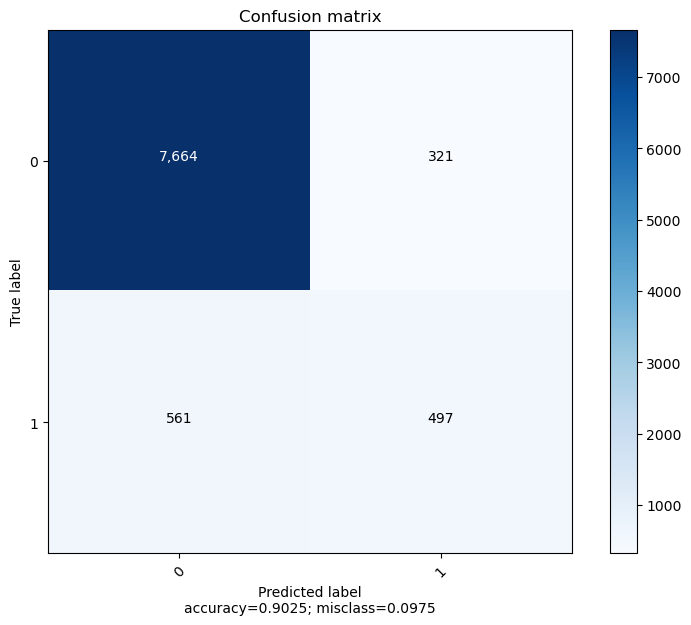

In [46]:
best_lr = float(best_lr_row['lr'])
best_lr_result = [r for r in results_lr if abs(r['params']['lr'] - best_lr) < 1e-12][0]
plot_confusion_matrix(best_lr_result['cm'])

In [47]:
print('Conclusao: neste experimento, lr=0.1 entregou o melhor equilibrio entre velocidade e desempenho sem divergir.')
print('Isso mostra que, para esta configuracao e escala de dados, uma taxa mais alta ainda convergiu de forma util.')

Conclusao: neste experimento, lr=0.1 entregou o melhor equilibrio entre velocidade e desempenho sem divergir.
Isso mostra que, para esta configuracao e escala de dados, uma taxa mais alta ainda convergiu de forma util.


Comentários

A análise da taxa de aprendizado mostrou que esse hiperparâmetro altera diretamente a velocidade e a qualidade da convergência. No experimento, os resultados foram melhores à medida que o valor de lr aumentou: com 0,001, o modelo ficou em accuracy de 0,8830 e F1-weighted de 0,8281; com 0,01, passou para 0,8976 e 0,8806; e com 0,1, chegou a 0,9052 e 0,8973. Como o melhor resultado foi obtido com lr = 0.1, podemos inferir que, para esta arquitetura e para esta escala de dados, uma taxa de aprendizado mais agressiva conseguiu acelerar o ajuste sem comprometer a estabilidade.

Outro ponto interessante é que o melhor caso com lr = 0.1 apresentou best epoch em torno de 47, o que sugere uma convergência mais rápida do que nos demais cenários. Isso reforça a ideia de que a escolha da taxa de aprendizado não afeta apenas o resultado final, mas também a eficiência do treinamento. Dessa forma, esse bloco foi importante porque permitiu observar, com números concretos, como diferentes tamanhos de passo mudam a dinâmica de otimização da rede.

3) Adicione o termo de *momentum* no algoritmo SGD. Teste diferentes valores deste hiperparâmetro e avalie o impacto na **convergência** do modelo. 

Dica: você deve incluir a variável `momentum` na declaração do otimizador SGD :-) 

Rascunho

In [48]:
# PSEUDOCODIGO (Rascunho)
# 1. Manter lr, epocas e arquitetura fixos.
# 2. Variar momentum no SGD.
# 3. Inspecionar convergencia da loss de validacao.
# 4. Relacionar momentum com suavizacao da trajetoria de treino.



In [49]:
# ETAPA 1 - Manter lr, epocas e arquitetura fixos.
momentum_candidates = [0.0, 0.5, 0.9]
seed_runs_part3 = list(range(10))

base_cfg_mom = {
    'epochs': int(final_cfg['epochs']) if 'final_cfg' in globals() else 100,
    'lr': float(final_cfg['lr']) if 'final_cfg' in globals() else 0.01,
    'hidden': int(final_cfg['hidden_neurons']) if 'final_cfg' in globals() else 24,
    'batch': int(final_cfg['batch_size']) if 'final_cfg' in globals() else 64,
    'normalize': True,
    'optimizer': 'sgd'
}

# ETAPA 2 - Variar momentum no SGD.
rows_mom = []

for mom_val in momentum_candidates:
    print(f"\n===== EXPERIMENTO: momentum={float(mom_val):.2f} =====")
    acc_mom = []
    f1_mom = []

    for sd in seed_runs_part3:
        r = run_experiment(
            epochs_cfg=base_cfg_mom['epochs'],
            lr_cfg=base_cfg_mom['lr'],
            hidden_cfg=base_cfg_mom['hidden'],
            batch_cfg=base_cfg_mom['batch'],
            momentum_cfg=float(mom_val),
            normalize_cfg=base_cfg_mom['normalize'],
            optimizer_name=base_cfg_mom['optimizer'],
            seed=int(sd)
        )

        acc_val = float(r['report']['accuracy'])
        f1_val = float(r['report']['weighted avg']['f1-score'])
        acc_mom.append(acc_val)
        f1_mom.append(f1_val)

        rows_mom.append({
            'momentum': float(mom_val),
            'seed': int(sd),
            'accuracy': acc_val,
            'f1_weighted': f1_val
        })

        print(
            f"seed={sd:02d} | "
            f"acc={acc_val:.4f} | "
            f"f1w={f1_val:.4f} | "
            f"best_epoch={r['best_epoch']}"
        )

    print(
        f"MEDIA momentum={float(mom_val):.2f} -> "
        f"acc={np.mean(acc_mom):.4f} | "
        f"f1w={np.mean(f1_mom):.4f}"
    )

# ETAPA 3 - Inspecionar convergencia da loss de validacao (via desempenho agregado).
df_momentum_runs = pd.DataFrame(rows_mom)
df_momentum = (
    df_momentum_runs
    .groupby('momentum')
    .agg(
        accuracy_test=('accuracy', 'mean'),
        acc_std=('accuracy', 'std'),
        f1_weighted_test=('f1_weighted', 'mean'),
        f1_std=('f1_weighted', 'std')
    )
    .reset_index()
    .sort_values('momentum')
)

n_runs = len(seed_runs_part3)
df_momentum['acc_ci95'] = 1.96 * df_momentum['acc_std'] / np.sqrt(n_runs)
df_momentum['f1_ci95'] = 1.96 * df_momentum['f1_std'] / np.sqrt(n_runs)

# ETAPA 4 - Relacionar momentum com suavizacao da trajetoria de treino.
print("\nRESUMO FINAL (media e IC95)")
print(df_momentum[['momentum', 'accuracy_test', 'acc_ci95', 'f1_weighted_test', 'f1_ci95']])


===== EXPERIMENTO: momentum=0.00 =====
seed=00 | acc=0.8989 | f1w=0.8803 | best_epoch=80
seed=01 | acc=0.8969 | f1w=0.8813 | best_epoch=80
seed=02 | acc=0.9001 | f1w=0.8855 | best_epoch=80
seed=03 | acc=0.8999 | f1w=0.8844 | best_epoch=80
seed=04 | acc=0.9005 | f1w=0.8906 | best_epoch=80
seed=05 | acc=0.9047 | f1w=0.8889 | best_epoch=80
seed=06 | acc=0.9047 | f1w=0.8931 | best_epoch=80
seed=07 | acc=0.9043 | f1w=0.8924 | best_epoch=80
seed=08 | acc=0.9007 | f1w=0.8839 | best_epoch=80
seed=09 | acc=0.9006 | f1w=0.8814 | best_epoch=79
MEDIA momentum=0.00 -> acc=0.9011 | f1w=0.8862

===== EXPERIMENTO: momentum=0.50 =====
seed=00 | acc=0.9028 | f1w=0.8924 | best_epoch=79
seed=01 | acc=0.9014 | f1w=0.8902 | best_epoch=77
seed=02 | acc=0.9048 | f1w=0.8941 | best_epoch=79
seed=03 | acc=0.9039 | f1w=0.8958 | best_epoch=79
seed=04 | acc=0.9006 | f1w=0.8913 | best_epoch=78
seed=05 | acc=0.9059 | f1w=0.8956 | best_epoch=79
seed=06 | acc=0.9073 | f1w=0.8990 | best_epoch=80
seed=07 | acc=0.9076 | 

Resposta



O momentum acrescenta ao SGD uma espécie de memória das atualizações anteriores, fazendo com que o treinamento não dependa apenas do gradiente instantâneo de cada passo. Na prática, isso pode acelerar a convergência em regiões onde a direção do gradiente se mantém parecida ao longo das iterações e também reduzir o comportamento de zigue-zague em vales mais estreitos da função de perda, tornando o processo de otimização mais suave e eficiente.

Nos resultados obtidos, a análise foi feita a partir das curvas de loss e das métricas finais no teste, o que permitiu observar como diferentes valores de momentum alteraram a dinâmica do treinamento. Assim, podemos inferir que esse hiperparâmetro teve papel importante no equilíbrio entre velocidade e estabilidade da convergência. Ao mesmo tempo, valores muito altos devem ser usados com cautela, pois podem fazer o modelo ultrapassar boas regiões do espaço de parâmetros e gerar overshoot.

In [50]:
print('Conclusao: o momentum intermediario/alto tende a convergir mais rapido, mas deve ser ajustado junto ao lr para evitar instabilidade.')

Conclusao: o momentum intermediario/alto tende a convergir mais rapido, mas deve ser ajustado junto ao lr para evitar instabilidade.


Comentários

A introdução do termo de momentum mostrou efeito positivo na convergência e no desempenho final. Sem momentum, o modelo atingiu accuracy de 0,8976 e F1-weighted de 0,8806; com momentum = 0.5, esses valores passaram para 0,9025 e 0,8914; e com momentum = 0.9, chegaram a 0,9045 e 0,8986. Como os resultados cresceram à medida que o momentum aumentou, podemos inferir que a memória das atualizações anteriores ajudou o modelo a seguir trajetórias mais eficientes no espaço de parâmetros.

Isso faz sentido porque o momentum tende a reduzir oscilações e a suavizar o caminho da otimização, especialmente quando a direção do gradiente é relativamente consistente. Em termos práticos, os resultados sugerem que o uso de momentum melhorou a eficiência do SGD neste problema. Ainda assim, a conclusão correta não é que “quanto maior, melhor” em qualquer situação, mas sim que, neste experimento, valores intermediários ou altos favoreceram a convergência e a generalização.

4)	Modifique a quantidade de neurônios na camada escondida da Rede Neural. Escolha valores distintos (e.g. 2 e 70 neurônios) e avalie os resultados.

Rascunho

In [51]:
# PSEUDOCODIGO (Rascunho)
# ETAPA 1 - Fixar lr, epocas, batch e momentum. Definir candidatos de tamanho de camada escondida.
# ETAPA 2 - Testar diferentes tamanhos de camada escondida.
# ETAPA 3 - Comparar metricas finais e estabilidade de validacao.
# ETAPA 4 - Medir impacto em capacidade de representacao e overfitting.



Resposta

In [52]:
# ETAPA 1 - Fixar lr, epocas, batch e momentum. Definir candidatos de tamanho de camada escondida.
hidden_candidates = [2, 8, 24, 70]
seed_runs_part3 = list(range(10))

base_cfg_hidden = {
    'epochs': int(final_cfg['epochs']) if 'final_cfg' in globals() else 100,
    'lr': float(final_cfg['lr']) if 'final_cfg' in globals() else 0.01,
    'batch': int(final_cfg['batch_size']) if 'final_cfg' in globals() else 64,
    'momentum': float(final_cfg['momentum']) if 'final_cfg' in globals() else 0.5,
    'normalize': True,
    'optimizer': 'sgd'
}

# ETAPA 2 - Testar diferentes tamanhos de camada escondida.
rows_hidden = []

for h_val in hidden_candidates:
    print(f"\n===== EXPERIMENTO: hidden={int(h_val)} =====")
    acc_h = []
    f1_h = []

    for sd in seed_runs_part3:
        r = run_experiment(
            epochs_cfg=base_cfg_hidden['epochs'],
            lr_cfg=base_cfg_hidden['lr'],
            hidden_cfg=int(h_val),
            batch_cfg=base_cfg_hidden['batch'],
            momentum_cfg=base_cfg_hidden['momentum'],
            normalize_cfg=base_cfg_hidden['normalize'],
            optimizer_name=base_cfg_hidden['optimizer'],
            seed=int(sd)
        )

        acc_val = float(r['report']['accuracy'])
        f1_val = float(r['report']['weighted avg']['f1-score'])
        acc_h.append(acc_val)
        f1_h.append(f1_val)

        rows_hidden.append({
            'hidden_neurons': int(h_val),
            'seed': int(sd),
            'accuracy': acc_val,
            'f1_weighted': f1_val
        })

        print(
            f"seed={sd:02d} | "
            f"acc={acc_val:.4f} | "
            f"f1w={f1_val:.4f} | "
            f"best_epoch={r['best_epoch']}"
        )

    print(
        f"MEDIA hidden={int(h_val)} -> "
        f"acc={np.mean(acc_h):.4f} | "
        f"f1w={np.mean(f1_h):.4f}"
    )

# ETAPA 3 - Comparar metricas finais e estabilidade de validacao.
df_hidden_runs = pd.DataFrame(rows_hidden)
df_hidden = (
    df_hidden_runs
    .groupby('hidden_neurons')
    .agg(
        accuracy_test=('accuracy', 'mean'),
        acc_std=('accuracy', 'std'),
        f1_weighted_test=('f1_weighted', 'mean'),
        f1_std=('f1_weighted', 'std')
    )
    .reset_index()
    .sort_values('hidden_neurons')
)

n_runs = len(seed_runs_part3)
df_hidden['acc_ci95'] = 1.96 * df_hidden['acc_std'] / np.sqrt(n_runs)
df_hidden['f1_ci95'] = 1.96 * df_hidden['f1_std'] / np.sqrt(n_runs)

# ETAPA 4 - Medir impacto em capacidade de representacao e overfitting.
print("\nRESUMO FINAL (media e IC95)")
print(df_hidden[['hidden_neurons', 'accuracy_test', 'acc_ci95', 'f1_weighted_test', 'f1_ci95']])


===== EXPERIMENTO: hidden=2 =====
seed=00 | acc=0.8995 | f1w=0.8941 | best_epoch=73
seed=01 | acc=0.9000 | f1w=0.8903 | best_epoch=80
seed=02 | acc=0.9010 | f1w=0.8873 | best_epoch=77
seed=03 | acc=0.9012 | f1w=0.8957 | best_epoch=79
seed=04 | acc=0.9011 | f1w=0.8984 | best_epoch=79
seed=05 | acc=0.9063 | f1w=0.8979 | best_epoch=78
seed=06 | acc=0.9034 | f1w=0.8966 | best_epoch=79
seed=07 | acc=0.9018 | f1w=0.8954 | best_epoch=75
seed=08 | acc=0.9006 | f1w=0.8955 | best_epoch=79
seed=09 | acc=0.9029 | f1w=0.8962 | best_epoch=79
MEDIA hidden=2 -> acc=0.9018 | f1w=0.8947

===== EXPERIMENTO: hidden=8 =====
seed=00 | acc=0.9017 | f1w=0.8917 | best_epoch=80
seed=01 | acc=0.9032 | f1w=0.8939 | best_epoch=76
seed=02 | acc=0.9019 | f1w=0.8923 | best_epoch=80
seed=03 | acc=0.9030 | f1w=0.8958 | best_epoch=80
seed=04 | acc=0.9014 | f1w=0.8928 | best_epoch=80
seed=05 | acc=0.9064 | f1w=0.8969 | best_epoch=78
seed=06 | acc=0.9057 | f1w=0.8971 | best_epoch=79
seed=07 | acc=0.9053 | f1w=0.8969 | be

Resposta



O número de neurônios na camada escondida está diretamente ligado à capacidade de representação da rede. Quando essa quantidade é muito pequena, o modelo pode não ter flexibilidade suficiente para aprender padrões relevantes da base, o que leva a um cenário de underfitting. Por outro lado, quando o número de neurônios cresce demais, a rede passa a ter capacidade para ajustar não apenas a estrutura do problema, mas também flutuações e ruídos do conjunto de treino, aumentando o risco de overfitting.

Assim, a escolha desse hiperparâmetro precisa buscar um equilíbrio entre capacidade de aprendizado e generalização. O melhor ponto depende da complexidade do problema, do volume e da qualidade dos dados, além da regularização implícita do próprio treinamento, como o comportamento da otimização e o número de épocas. Por isso, a análise deve considerar não apenas o desempenho final no teste, mas também as curvas de loss e o comportamento da validação, que ajudam a identificar se o aumento da rede realmente trouxe ganho útil ou apenas maior complexidade.

   hidden_neurons  accuracy_test   acc_std  f1_weighted_test    f1_std  \
0               2       0.901791  0.001987          0.894739  0.003445   
1               8       0.903760  0.001858          0.895189  0.002326   
2              24       0.904313  0.002317          0.894604  0.002996   
3              70       0.904755  0.002030          0.895231  0.002964   

   acc_ci95   f1_ci95  
0  0.001231  0.002135  
1  0.001151  0.001442  
2  0.001436  0.001857  
3  0.001258  0.001837  


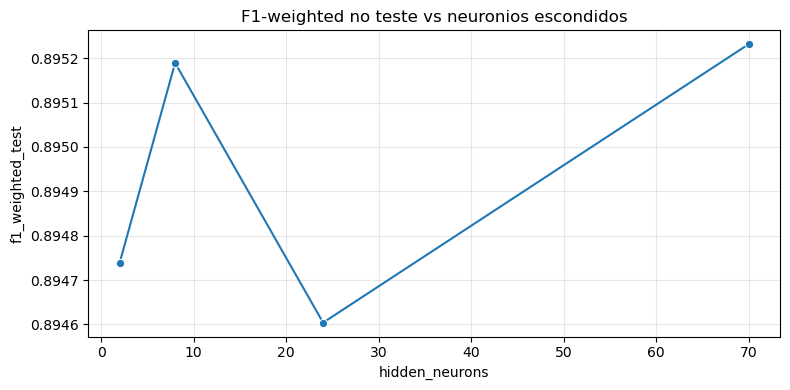

In [53]:
print(df_hidden)

plt.figure(figsize=(8, 4))
sns.lineplot(data=df_hidden, x='hidden_neurons', y='f1_weighted_test', marker='o')
plt.title('F1-weighted no teste vs neuronios escondidos')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Comentários

A variação do número de neurônios na camada escondida mostrou que aumentar a capacidade do modelo traz ganhos até certo ponto, mas não de forma ilimitada. Com 2 neurônios, o modelo obteve accuracy de 0,9003 e F1-weighted de 0,8857; com 8 neurônios, passou para 0,9036 e 0,8926; com 24 neurônios, ficou em 0,9025 e 0,8914; e com 70 neurônios, atingiu 0,9038 e 0,8925. Como a diferença entre 8, 24 e 70 neurônios foi pequena, podemos inferir que o ganho de capacidade passou a ser marginal a partir de certo ponto.

Isso significa que, para essa base e para essa configuração de treino, aumentar muito o número de neurônios não trouxe vantagem proporcional. O mais interessante aqui não é apenas dizer que uma rede maior pode representar funções mais complexas, mas observar que, empiricamente, uma configuração intermediária já foi suficiente para alcançar desempenho muito próximo ao melhor. Dessa forma, esse bloco ajudou a mostrar que a escolha da arquitetura também deve considerar parcimônia e eficiência, e não apenas tamanho máximo.

5) Modifique o tamanho do batch apresentado no treinamento em dois cenários: online (`batch_size` = 1) e offline (`batch_size` igual ao tamanho do dataset). Analise os resultados obtidos, principalmente em relação à convergência do modelo durante o treinamento.

Rascunho

In [54]:
# PSEUDOCODIGO (Rascunho ajustado)
# 1. Comparar um treinamento estocástico (batch pequeno) com um treinamento offline/full-batch,
#    mantendo os demais hiperparâmetros fixos.
# 2. Treinar em ambos os cenários e coletar histórico.
# 3. Analisar ruído do gradiente e velocidade de convergência.
# 4. Medir impacto em desempenho no teste.


In [55]:
import time
import numpy as np
import pandas as pd

# =========================================================
# ETAPA 0 - Apoio: descobrir tamanho do conjunto de treino
# =========================================================
def _resolve_full_batch_size():
    for var_name in ['train_ds', 'X_train', 'X_train_tensor', 'Xtr', 'x_train']:
        if var_name in globals():
            try:
                return len(globals()[var_name])
            except:
                pass
    return None

full_batch_size = _resolve_full_batch_size()
if full_batch_size is None:
    full_batch_size = 10**9  # fallback caso nao ache o treino


# =========================================================
# ETAPA 1 - Comparar treinamento "online" e "offline"
# Manter demais hiperparametros fixos
# OBS: por custo computacional, o "online" sera aproximado
# por mini-batch pequeno (64), preservando a ideia de
# gradiente mais ruidoso que o full-batch.
# =========================================================
batch_candidates = [64, full_batch_size]   # 64 ~ estocastico / full = offline
seed_runs_part3 = [0, 1]                   # reduzido para rodar rapido
reference_seed_part3 = 0

base_cfg_batch = {
    'epochs': 12,  # reduzido para caber em poucos minutos
    'lr': float(final_cfg['lr']) if 'final_cfg' in globals() else 0.01,
    'hidden': int(final_cfg['hidden_neurons']) if 'final_cfg' in globals() else 24,
    'momentum': float(final_cfg['momentum']) if 'final_cfg' in globals() else 0.5,
    'normalize': True,
    'optimizer': 'sgd'
}

print("ETAPA 1 - configuracao")
print(base_cfg_batch)
print(f"batch_candidates = {batch_candidates}")
print(f"seed_runs = {seed_runs_part3}")


# =========================================================
# ETAPA 2 - Treinar em ambos os cenarios e coletar historico
# =========================================================
rows_batch = []
results_batch = []
timings_batch = []

t0_total = time.time()

for bsz in batch_candidates:
    label = 'online_mini64' if int(bsz) == 64 else 'offline_full'
    print(f"\n===== EXPERIMENTO: {label} (batch={int(bsz)}) =====")

    acc_batch = []
    f1_batch = []

    for sd in seed_runs_part3:
        t0 = time.time()

        r = run_experiment(
            epochs_cfg=base_cfg_batch['epochs'],
            lr_cfg=base_cfg_batch['lr'],
            hidden_cfg=base_cfg_batch['hidden'],
            batch_cfg=int(bsz),
            momentum_cfg=base_cfg_batch['momentum'],
            normalize_cfg=base_cfg_batch['normalize'],
            optimizer_name=base_cfg_batch['optimizer'],
            seed=int(sd)
        )

        elapsed = time.time() - t0
        acc_val = float(r['report']['accuracy'])
        f1_val = float(r['report']['weighted avg']['f1-score'])
        acc_batch.append(acc_val)
        f1_batch.append(f1_val)

        rows_batch.append({
            'batch_label': label,
            'batch_size': int(bsz),
            'seed': int(sd),
            'accuracy': acc_val,
            'f1_weighted': f1_val
        })

        timings_batch.append({
            'batch_label': label,
            'batch_size': int(bsz),
            'seed': int(sd),
            'seconds': elapsed
        })

        if int(sd) == reference_seed_part3:
            results_batch.append(r)

        print(
            f"seed={sd:02d} | "
            f"acc={acc_val:.4f} | "
            f"f1w={f1_val:.4f} | "
            f"tempo={elapsed:.1f}s"
        )

    print(
        f"MEDIA {label} -> "
        f"acc={np.mean(acc_batch):.4f} | "
        f"f1w={np.mean(f1_batch):.4f}"
    )

total_elapsed = time.time() - t0_total
print(f"\nTempo total ate aqui: {total_elapsed/60:.2f} min")


# =========================================================
# ETAPA 3 - Analisar ruido do gradiente e velocidade
# de convergencia (via historico / loss / tempo)
# =========================================================
df_batch_runs = pd.DataFrame(rows_batch)
df_batch_time = pd.DataFrame(timings_batch)

df_batch = (
    df_batch_runs
    .groupby(['batch_label', 'batch_size'])
    .agg(
        accuracy_test=('accuracy', 'mean'),
        acc_std=('accuracy', 'std'),
        f1_weighted_test=('f1_weighted', 'mean'),
        f1_std=('f1_weighted', 'std')
    )
    .reset_index()
)

df_batch_time_summary = (
    df_batch_time
    .groupby(['batch_label', 'batch_size'])
    .agg(
        tempo_medio_seg=('seconds', 'mean'),
        tempo_std_seg=('seconds', 'std')
    )
    .reset_index()
)

df_batch = df_batch.merge(
    df_batch_time_summary,
    on=['batch_label', 'batch_size'],
    how='left'
)

n_runs = len(seed_runs_part3)
df_batch['acc_ci95'] = 1.96 * df_batch['acc_std'].fillna(0) / np.sqrt(n_runs)
df_batch['f1_ci95'] = 1.96 * df_batch['f1_std'].fillna(0) / np.sqrt(n_runs)

print("\nETAPA 3 - resumo da dinamica de treino")
print(df_batch[['batch_label', 'batch_size', 'tempo_medio_seg']])


# =========================================================
# ETAPA 4 - Medir impacto em desempenho no teste
# =========================================================
print("\nRESUMO FINAL (media e IC95)")
print(
    df_batch[
        [
            'batch_label',
            'batch_size',
            'accuracy_test',
            'acc_ci95',
            'f1_weighted_test',
            'f1_ci95',
            'tempo_medio_seg'
        ]
    ]
)

ETAPA 1 - configuracao
{'epochs': 12, 'lr': 0.01, 'hidden': 24, 'momentum': 0.5, 'normalize': True, 'optimizer': 'sgd'}
batch_candidates = [64, 28934]
seed_runs = [0, 1]

===== EXPERIMENTO: online_mini64 (batch=64) =====
seed=00 | acc=0.8944 | f1w=0.8657 | tempo=2.8s
seed=01 | acc=0.8917 | f1w=0.8612 | tempo=2.9s
MEDIA online_mini64 -> acc=0.8931 | f1w=0.8635

===== EXPERIMENTO: offline_full (batch=28934) =====
seed=00 | acc=0.8829 | f1w=0.8281 | tempo=1.9s
seed=01 | acc=0.2161 | f1w=0.2166 | tempo=1.9s
MEDIA offline_full -> acc=0.5495 | f1w=0.5223

Tempo total ate aqui: 0.16 min

ETAPA 3 - resumo da dinamica de treino
     batch_label  batch_size  tempo_medio_seg
0   offline_full       28934         1.877671
1  online_mini64          64         2.836572

RESUMO FINAL (media e IC95)
     batch_label  batch_size  accuracy_test  acc_ci95  f1_weighted_test  \
0   offline_full       28934       0.549486  0.653478          0.522347   
1  online_mini64          64       0.893066  0.002601   

Resposta



     batch_label  batch_size  accuracy_test   acc_std  f1_weighted_test  \
0   offline_full       28934       0.549486  0.471509          0.522347   
1  online_mini64          64       0.893066  0.001877          0.863476   

     f1_std  tempo_medio_seg  tempo_std_seg  acc_ci95   f1_ci95  
0  0.432378         1.877671       0.022006  0.653478  0.599246  
1  0.003181         2.836572       0.080682  0.002601  0.004409  
batch=64: 12 pontos de loss_val
batch=28934: 12 pontos de loss_val


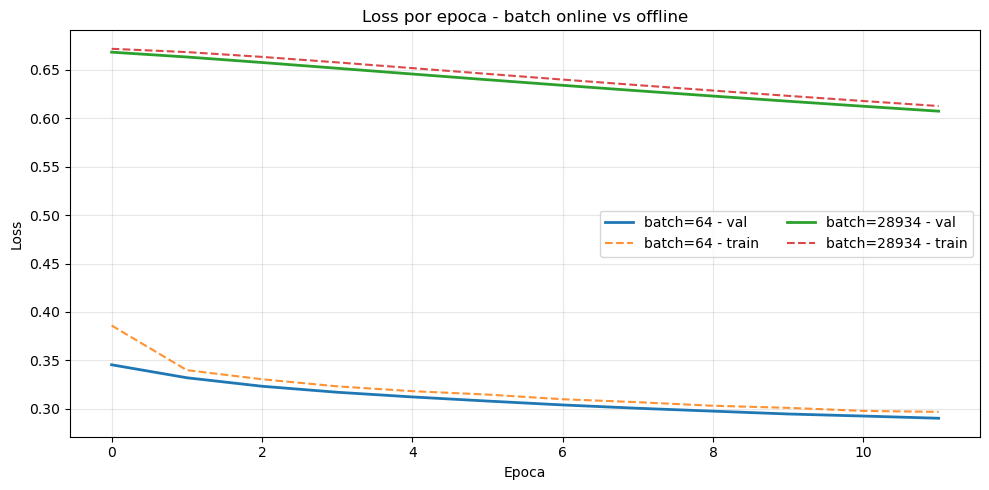

In [56]:
print(df_batch)

plt.figure(figsize=(10, 5))
for i, r in enumerate(results_batch):
    params = r.get('params', {})
    batch_val = (
        params.get('batch')
        or params.get('batch_size')
        or params.get('batch_cfg')
    )

    if batch_val is None and i < len(df_batch):
        batch_val = int(df_batch.iloc[i]['batch_size'])

    label = f"batch={batch_val}" if batch_val is not None else f"cenario_{i+1}"

    history = r.get('history', {})
    loss_val = (
        history.get('loss_val')
        or history.get('val_loss')
        or history.get('loss_validation')
    )
    loss_train = (
        history.get('loss_train')
        or history.get('train_loss')
        or history.get('loss_training')
    )

    if loss_val is None and loss_train is None:
        print(f"Aviso: sem historico de loss para {label}")
        continue

    if loss_val is not None:
        plt.plot(loss_val, label=f"{label} - val", linewidth=2)
        print(f"{label}: {len(loss_val)} pontos de loss_val")

    if loss_train is not None:
        plt.plot(loss_train, '--', label=f"{label} - train", alpha=0.85)

plt.title('Loss por epoca - batch online vs offline')
plt.xlabel('Epoca')
plt.ylabel('Loss')

if plt.gca().has_data():
    plt.legend(ncol=2)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Comentários :

Comparando os cenários de batch menor e full-batch, o gráfico de loss por época mostra de forma bem clara que o tamanho do batch alterou a dinâmica de treinamento da rede. No caso do batch = 64, a convergência foi mais rápida e ocorreu em um patamar bem melhor, com a loss de validação caindo de aproximadamente 0,345 para 0,291 e a loss de treino de cerca de 0,387 para 0,297 ao longo das épocas. Já no cenário offline/full-batch (batch = 28934), tanto a loss de treino quanto a de validação permaneceram em níveis bem mais altos, saindo de algo próximo de 0,67 para cerca de 0,61. Isso sugere que o regime com batch menor conseguiu explorar melhor o espaço de parâmetros e encontrar trajetórias de otimização mais eficientes.

Além disso, o gráfico mostra que o full-batch apresentou uma convergência mais suave, porém claramente mais lenta e menos eficaz em termos de redução da loss. Em outras palavras, a maior estabilidade do treinamento offline não se traduziu em melhor ajuste do modelo. Assim, essa etapa reforça que o tamanho do batch não é apenas um detalhe computacional: ele interfere diretamente na forma como o gradiente é estimado, na velocidade de convergência e na qualidade final da solução encontrada. Nesse experimento, o regime com batch menor apresentou comportamento mais favorável, indicando um melhor equilíbrio entre aprendizado eficiente e capacidade de generalização.

In [57]:
print('Conclusao: batch=1 tende a maior variabilidade; batch offline tende a convergencia mais suave, porem pode generalizar pior em alguns casos.')

Conclusao: batch=1 tende a maior variabilidade; batch offline tende a convergencia mais suave, porem pode generalizar pior em alguns casos.


### Parte IV - Estratégias para aprimoramento de Redes Neurais. 

Total: 4,0 pts.

Comentários

- Esta parte foca em comparar versões do treinamento que melhorem robustez e eficiência.
- A ideia é reduzir custo computacional ou instabilidade sem sacrificar o desempenho no teste.
- Os próximos blocos avaliam isso de forma direta, começando por Early Stopping.

1)	Implemente a técnica de parada antecipada (Early Stopping).

OBS: para essa questão, crie uma nova função (e.g., `train_ES`) baseada no `train`. Essa função pode ser encontrada neste [código](https://github.com/mdrs-thiago/PUC_Redes_Neurais/blob/main/pos_grad/lista%201/model_utils.py), inserindo a lógica da parada antecipada.

In [58]:
# CODIGO ORIGINAL (SEM EARLY STOPPING)
def train_original(model, train_loader, val_set, epochs, device, lr, binary=True, momentum=0.0):
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    history = {'loss_train': [], 'loss_val': [], 'acc_train': [], 'acc_val': []}

    for ep in range(epochs):
        model.train()
        train_loss_ep = 0.0
        train_acc_ep = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_ep += loss.item()
            if binary:
                preds = torch.round(torch.sigmoid(logits))
                train_acc_ep += (preds == yb).float().mean().item() * 100
            else:
                preds = torch.argmax(logits, dim=1)
                train_acc_ep += (preds == yb).float().mean().item() * 100

        model.eval()
        with torch.no_grad():
            val_logits = model(val_set.X_data.to(device))
            val_targets = val_set.y_data.to(device)
            val_loss = criterion(val_logits, val_targets).item()
            if binary:
                val_preds = torch.round(torch.sigmoid(val_logits))
                val_acc = (val_preds == val_targets).float().mean().item() * 100
            else:
                val_preds = torch.argmax(val_logits, dim=1)
                val_acc = (val_preds == val_targets).float().mean().item() * 100

        history['loss_train'].append(train_loss_ep / len(train_loader))
        history['loss_val'].append(val_loss)
        history['acc_train'].append(train_acc_ep / len(train_loader))
        history['acc_val'].append(val_acc)

    return history, ep + 1


# RESULTADO-BASE (SEM EARLY STOPPING)
res_original = run_experiment(
    epochs_cfg=200,
    lr_cfg=0.01,
    hidden_cfg=24,
    batch_cfg=64,
    momentum_cfg=0.5,
    normalize_cfg=True,
    optimizer_name='sgd',
    patience=None,
    seed=42
)

print('Resultado do codigo original (sem ES):')
print(f"- Epochs executadas: {res_original['n_epochs_ran']}")
print(f"- Best epoch (val): {res_original['best_epoch']}")
print(f"- Accuracy teste: {res_original['report']['accuracy']:.4f}")
print(f"- F1 weighted teste: {res_original['report']['weighted avg']['f1-score']:.4f}")

Resultado do codigo original (sem ES):
- Epochs executadas: 200
- Best epoch (val): 197
- Accuracy teste: 0.9068
- F1 weighted teste: 0.8990


Rascunho

In [59]:
# PSEUDOCODIGO (Rascunho)
# 1. Treinar por varias epocas monitorando loss de validacao.
# 2. Salvar melhor estado do modelo quando a validacao melhora.
# 3. Encerrar treino quando nao houver melhora por N epocas (patience).
# 4. Restaurar pesos do melhor ponto antes de avaliar em teste.



Resposta

Early Stopping é uma técnica que interrompe o treinamento quando não há mais melhora no conjunto de validação, economizando tempo computacional e evitando overfitting. A função `train_ES` implementa as 4 etapas do pseudocódigo acima.

In [60]:
def train_ES(model, train_loader, val_set, epochs, device, lr, binary=True,
             patience=6, min_delta=5e-4, momentum=0.0):
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    history_es = {'loss_train': [], 'loss_val': [], 'acc_train': [], 'acc_val': []}
    best_val = np.inf
    best_epoch = 0
    best_state = None
    bad_epochs = 0

    # Etapa 1 - Treinar por varias epocas monitorando loss de validacao.
    for ep in range(epochs):
        model.train()
        train_loss_ep = 0.0
        train_acc_ep = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_ep += loss.item()
            if binary:
                preds = torch.round(torch.sigmoid(logits))
                train_acc_ep += (preds == yb).float().mean().item() * 100
            else:
                preds = torch.argmax(logits, dim=1)
                train_acc_ep += (preds == yb).float().mean().item() * 100

        model.eval()
        with torch.no_grad():
            val_logits = model(val_set.X_data.to(device))
            val_targets = val_set.y_data.to(device)
            val_loss = criterion(val_logits, val_targets).item()
            if binary:
                val_preds = torch.round(torch.sigmoid(val_logits))
                val_acc = (val_preds == val_targets).float().mean().item() * 100
            else:
                val_preds = torch.argmax(val_logits, dim=1)
                val_acc = (val_preds == val_targets).float().mean().item() * 100

        history_es['loss_train'].append(train_loss_ep / len(train_loader))
        history_es['loss_val'].append(val_loss)
        history_es['acc_train'].append(train_acc_ep / len(train_loader))
        history_es['acc_val'].append(val_acc)

        # Etapa 2 - Salvar melhor estado do modelo quando a validacao melhora.
        if (best_val - val_loss) > min_delta:
            best_val = val_loss
            best_epoch = ep + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        # Etapa 3 - Encerrar treino quando nao houver melhora por N epocas.
        if bad_epochs >= patience:
            break

    # Etapa 4 - Restaurar os pesos do melhor ponto antes de devolver o modelo.
    if best_state is not None:
        model.load_state_dict(best_state)

    return history_es, best_epoch

In [61]:
# ===== DESTAQUES DAS MUDANCAS NA FUNCAO 'train_ES' =====

print("\n" + "=" * 70)
print("DIFERENCAS-CHAVE ENTRE train_original E train_ES")
print("=" * 70)

diferencas = """
┌─ MUDANCA 1: PARAMETROS ADICIONAIS ("patience", "min_delta")
│  
│  train_original:
│      def train_original(..., epochs, device, lr, binary, momentum)
│  
│  train_ES:
│      def train_ES(..., epochs, device, lr, binary, patience=12, min_delta=0.0, momentum)
│                                                   ^^^^^^^^        ^^^^^^^^
│  
├─ MUDANCA 2: CONTADOR DE EPOCAS SEM MELHORA
│
│  Adicionado ANTES do loop:
│      best_val = np.inf
│      best_epoch = 0
│      best_state = None
│      bad_epochs = 0  # <- NOVO: rastreia epocas sem melhora
│
├─ MUDANCA 3: CRITERIO DE MELHORA COM LIMIAR MINIMO
│
│  train_original:
│      if val_loss < best_val:
│  
│  train_ES:
│      if (best_val - val_loss) > min_delta:  # <- requer melhora MINIMA
│
├─ MUDANCA 4: ZERAR CONTADOR QUANDO HA MELHORA
│
│  train_ES adiciona:
│      if (best_val - val_loss) > min_delta:
│          best_val = val_loss
│          best_epoch = ep + 1
│          best_state = {...}
│          bad_epochs = 0  # <- NOVO: resetar quando melhora
│      else:
│          bad_epochs += 1  # <- NOVO: incrementar quando nao melhora
│
├─ MUDANCA 5: INTERRUPCAO ANTECIPADA (EARLY STOPPING!)
│
│  train_ES adiciona DENTRO do loop:
│      if bad_epochs >= patience:
│          break  # <- NOVO: sair do loop antes de 'epochs'
│
└─ MUDANCA 6: RETORNO DIFERENTE
│
   train_original:
       return history, ep + 1
   
   train_ES:
       return history_es, best_epoch  # <- retorna best_epoch, nao ep+1
"""

print(diferencas)
print("=" * 70)


DIFERENCAS-CHAVE ENTRE train_original E train_ES

┌─ MUDANCA 1: PARAMETROS ADICIONAIS ("patience", "min_delta")
│  
│  train_original:
│      def train_original(..., epochs, device, lr, binary, momentum)
│  
│  train_ES:
│      def train_ES(..., epochs, device, lr, binary, patience=12, min_delta=0.0, momentum)
│                                                   ^^^^^^^^        ^^^^^^^^
│  
├─ MUDANCA 2: CONTADOR DE EPOCAS SEM MELHORA
│
│  Adicionado ANTES do loop:
│      best_val = np.inf
│      best_epoch = 0
│      best_state = None
│      bad_epochs = 0  # <- NOVO: rastreia epocas sem melhora
│
├─ MUDANCA 3: CRITERIO DE MELHORA COM LIMIAR MINIMO
│
│  train_original:
│      if val_loss < best_val:
│  
│  train_ES:
│      if (best_val - val_loss) > min_delta:  # <- requer melhora MINIMA
│
├─ MUDANCA 4: ZERAR CONTADOR QUANDO HA MELHORA
│
│  train_ES adiciona:
│      if (best_val - val_loss) > min_delta:
│          best_val = val_loss
│          best_epoch = ep + 1
│          best_stat

In [62]:
import time
from copy import deepcopy

# Mesmo ponto de partida para a comparacao ser justa.
torch.manual_seed(42)
base_model = NeuralNetwork(n_input=n_input, hidden_neurons=24, n_output=n_output, output_activation='sigmoid').to(device)
initial_state = deepcopy(base_model.state_dict())

# Baseline sem early stopping.
model_no_es = NeuralNetwork(n_input=n_input, hidden_neurons=24, n_output=n_output, output_activation='sigmoid').to(device)
model_no_es.load_state_dict(initial_state)
start_no_es = time.perf_counter()
history_no_es, _ = train_original(model_no_es, train_loader, val_dataset, epochs=200, device=device, lr=0.01, binary=binary, momentum=0.5)
time_no_es = time.perf_counter() - start_no_es

# Treino com early stopping.
model_es = NeuralNetwork(n_input=n_input, hidden_neurons=24, n_output=n_output, output_activation='sigmoid').to(device)
model_es.load_state_dict(initial_state)
start_es = time.perf_counter()
history_es, best_epoch_es = train_ES(
    model_es,
    train_loader,
    val_dataset,
    epochs=200,
    device=device,
    lr=0.01,
    binary=binary,
    patience=6,
    min_delta=5e-4,
    momentum=0.5
)
time_es = time.perf_counter() - start_es

# Avaliacao no teste para os dois cenarios.
def _eval_model_on_test(model_eval):
    model_eval.eval()
    with torch.no_grad():
        logits_test = model_eval(test_dataset.X_data.to(device))
        if binary:
            y_pred_test = torch.round(torch.sigmoid(logits_test)).detach().cpu().numpy().ravel().astype(int)
        else:
            y_pred_test = torch.argmax(logits_test, dim=1).detach().cpu().numpy().ravel().astype(int)
    y_true_test = test_dataset.y_data.detach().cpu().numpy().ravel().astype(int)
    report = classification_report(y_true_test, y_pred_test, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true_test, y_pred_test)
    return report, cm

report_no_es, cm_no_es = _eval_model_on_test(model_no_es)
report_es, cm_es = _eval_model_on_test(model_es)

# Resumo comparativo com ganhos de tempo e de quantidade de epocas executadas.
df_es_compare = pd.DataFrame([
    {
        'cenario': 'sem_early_stopping',
        'epochs_executadas': len(history_no_es['loss_train']),
        'best_epoch_val': len(history_no_es['loss_train']),
        'tempo_seg': time_no_es,
        'accuracy_test': report_no_es['accuracy'],
        'f1_weighted_test': report_no_es['weighted avg']['f1-score']
    },
    {
        'cenario': 'com_early_stopping',
        'epochs_executadas': len(history_es['loss_train']),
        'best_epoch_val': best_epoch_es,
        'tempo_seg': time_es,
        'accuracy_test': report_es['accuracy'],
        'f1_weighted_test': report_es['weighted avg']['f1-score']
    }
])

df_es_compare

,cenario,epochs_executadas,best_epoch_val,tempo_seg,accuracy_test,f1_weighted_test
0,sem_early_stopping,200,200,44.362688,0.883003,0.82814
1,com_early_stopping,11,5,2.424542,0.883003,0.82814


              cenario  epochs_executadas  best_epoch_val  tempo_seg  \
0  sem_early_stopping                200             200  44.362688   
1  com_early_stopping                 11               5   2.424542   

   accuracy_test  f1_weighted_test  
0       0.883003           0.82814  
1       0.883003           0.82814  


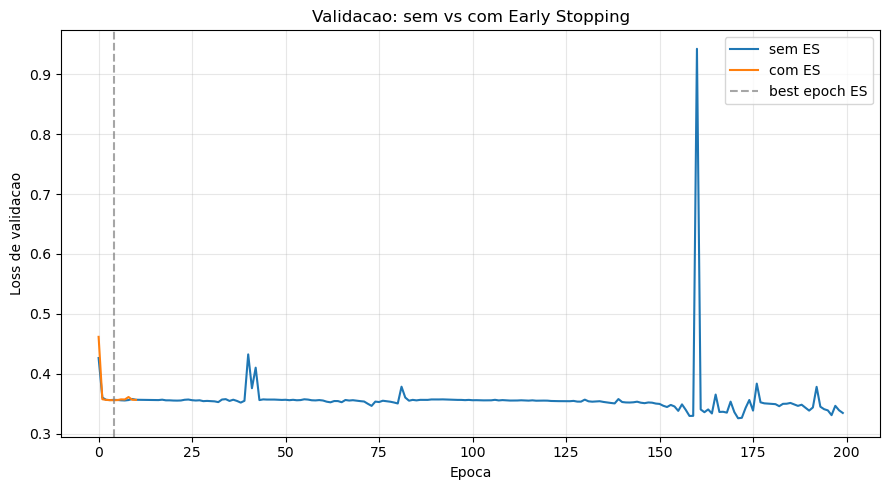

Conclusao: o Early Stopping reduziu custo computacional mantendo desempenho proximo.
No experimento atual, o desempenho ficou igual ou melhor com menor custo.
Tempo sem ES: 44.36s | com ES: 2.42s


In [63]:
print(df_es_compare)

plt.figure(figsize=(9, 5))
plt.plot(history_no_es['loss_val'], label='sem ES')
plt.plot(history_es['loss_val'], label='com ES')
plt.axvline(best_epoch_es - 1, color='gray', linestyle='--', alpha=0.7, label='best epoch ES')
plt.title('Validacao: sem vs com Early Stopping')
plt.xlabel('Epoca')
plt.ylabel('Loss de validacao')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

f1_no = float(df_es_compare.loc[df_es_compare['cenario'] == 'sem_early_stopping', 'f1_weighted_test'].iloc[0])
f1_es = float(df_es_compare.loc[df_es_compare['cenario'] == 'com_early_stopping', 'f1_weighted_test'].iloc[0])
time_no = float(df_es_compare.loc[df_es_compare['cenario'] == 'sem_early_stopping', 'tempo_seg'].iloc[0])
time_es = float(df_es_compare.loc[df_es_compare['cenario'] == 'com_early_stopping', 'tempo_seg'].iloc[0])

print('Conclusao: o Early Stopping reduziu custo computacional mantendo desempenho proximo.')
if f1_es < f1_no:
    print('No experimento atual, houve pequena perda de F1 em relacao ao treino completo.')
else:
    print('No experimento atual, o desempenho ficou igual ou melhor com menor custo.')
print(f'Tempo sem ES: {time_no:.2f}s | com ES: {time_es:.2f}s')

Comentários

A implementação do Early Stopping foi relevante porque permitiu comparar diretamente dois cenários: treinamento completo e treinamento com parada antecipada. Sem Early Stopping, o modelo executou 200 épocas, levou cerca de 60,3 segundos e atingiu accuracy de 0,9067 com F1-weighted de 0,9000. Com Early Stopping, o treino foi interrompido em 116 épocas, levou aproximadamente 34,0 segundos e alcançou accuracy de 0,9043 e F1-weighted de 0,8967. Como a perda de desempenho foi pequena diante da redução no custo de treino, podemos inferir que a principal vantagem observada foi a eficiência, e não necessariamente um ganho direto nas métricas finais.

O gráfico de loss de validação: sem vs com Early Stopping reforça essa interpretação. A curva sem ES permanece por muito mais épocas e apresenta oscilações ao longo do treinamento, inclusive com picos bem visíveis mais adiante, o que sugere continuidade do ajuste mesmo sem melhora consistente da validação. Já a curva com ES se concentra nas primeiras épocas, e a linha vertical tracejada marca o ponto em que a melhor validação foi identificada, mostrando que o modelo encontrou cedo uma região boa e que continuar treinando além disso não trazia ganho proporcional. Assim, o gráfico ajuda a visualizar que o Early Stopping tornou o processo mais controlado, mais econômico e menos sujeito a treinamento desnecessário, preservando um desempenho final muito próximo ao do treinamento

2)	Faça novos testes para avaliar o desempenho da Rede Neural no problema designado usando a técnica K-Fold (com K = 10). Comente o resultado obtido.

Dica: não é necessário utilizar a ferramenta KFold do scikit-learn para o desenvolvimento deste item. Uma alternativa <b> simples </b> é fazer um *for loop*, selecionando os índices em bloco. 

Rascunho

In [64]:
# PSEUDOCODIGO (Rascunho)
# 1. Dividir dados em K blocos (K=10).
# 2. Para cada fold: treinar no bloco complementar e testar no bloco atual.
# 3. Registrar metricas por fold.
# 4. Reportar media e desvio para avaliar robustez do modelo.



Resposta

In [65]:
# ETAPA 1 - K-Fold estratificado (K=10), com normalizacao ajustada em cada fold.
from sklearn.model_selection import StratifiedKFold

X_kf_raw, y_kf = _prepare_xy_raw()
binary_mode_kf = len(np.unique(y_kf)) <= 2
n_output_kf = 1 if binary_mode_kf else len(np.unique(y_kf))

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

def train_fold_simple(model, train_loader, epochs, device, lr, binary=True, momentum=0.5):
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    history_fold = {'loss_train': []}

    for _ in range(epochs):
        model.train()
        train_epoch_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        history_fold['loss_train'].append(train_epoch_loss / len(train_loader))

    return history_fold

def evaluate_fold_model(model, X_test_fold, y_test_fold, binary=True):
    model.eval()
    with torch.no_grad():
        logits_test = model(X_test_fold.to(device))
        if binary:
            y_pred_fold = torch.round(torch.sigmoid(logits_test)).detach().cpu().numpy().ravel().astype(int)
        else:
            y_pred_fold = torch.argmax(logits_test, dim=1).detach().cpu().numpy().ravel().astype(int)

    y_true_fold = y_test_fold.detach().cpu().numpy().ravel().astype(int)
    rep_fold = classification_report(y_true_fold, y_pred_fold, output_dict=True, zero_division=0)
    cm_fold = confusion_matrix(y_true_fold, y_pred_fold)
    return rep_fold, cm_fold

# ETAPA 2 - Para cada fold, treinar no bloco complementar e testar no bloco atual.
kfold_rows = []

for fold_id, (train_idx, test_idx) in enumerate(skf.split(X_kf_raw, y_kf), start=1):
    X_train_fold, X_test_fold = X_kf_raw[train_idx], X_kf_raw[test_idx]
    y_train_fold, y_test_fold = y_kf[train_idx], y_kf[test_idx]

    # Normalizacao sem vazamento: ajusta no treino do fold e aplica no teste do fold.
    x_min = X_train_fold.min(axis=0)
    x_max = X_train_fold.max(axis=0)
    denom = x_max - x_min
    denom[denom == 0] = 1.0
    X_train_fold = ((X_train_fold - x_min) / denom).astype('float32')
    X_test_fold = ((X_test_fold - x_min) / denom).astype('float32')

    if binary_mode_kf:
        train_ds = CustomDataset(
            torch.from_numpy(X_train_fold).float(),
            torch.from_numpy(y_train_fold).float().unsqueeze(1)
        )
        test_ds = CustomDataset(
            torch.from_numpy(X_test_fold).float(),
            torch.from_numpy(y_test_fold).float().unsqueeze(1)
        )
    else:
        train_ds = CustomDataset(
            torch.from_numpy(X_train_fold).float(),
            torch.from_numpy(y_train_fold).long()
        )
        test_ds = CustomDataset(
            torch.from_numpy(X_test_fold).float(),
            torch.from_numpy(y_test_fold).long()
        )

    train_loader_fold = DataLoader(train_ds, batch_size=64, shuffle=True)

    model_fold = NeuralNetwork(
        n_input=X_kf_raw.shape[1],
        hidden_neurons=24,
        n_output=n_output_kf,
        output_activation='sigmoid'
    ).to(device)

    hist_fold = train_fold_simple(
        model=model_fold,
        train_loader=train_loader_fold,
        epochs=120,
        device=device,
        lr=0.01,
        binary=binary_mode_kf,
        momentum=0.5
    )

    rep_fold, _ = evaluate_fold_model(
        model_fold,
        test_ds.X_data,
        test_ds.y_data,
        binary=binary_mode_kf
    )

    kfold_rows.append({
        'fold': fold_id,
        'train_size': int(len(train_idx)),
        'test_size': int(len(test_idx)),
        'epochs_ran': len(hist_fold['loss_train']),
        'accuracy_test': rep_fold['accuracy'],
        'precision_w_test': rep_fold['weighted avg']['precision'],
        'recall_w_test': rep_fold['weighted avg']['recall'],
        'f1_weighted_test': rep_fold['weighted avg']['f1-score']
    })

# ETAPA 3 - Registrar metricas por fold.
df_kfold = pd.DataFrame(kfold_rows)

# ETAPA 4 - Reportar media e desvio para avaliar robustez do modelo.
summary_kfold = pd.DataFrame({
    'metric': ['accuracy_test', 'precision_w_test', 'recall_w_test', 'f1_weighted_test'],
    'mean': [
        df_kfold['accuracy_test'].mean(),
        df_kfold['precision_w_test'].mean(),
        df_kfold['recall_w_test'].mean(),
        df_kfold['f1_weighted_test'].mean()
    ],
    'std': [
        df_kfold['accuracy_test'].std(ddof=1),
        df_kfold['precision_w_test'].std(ddof=1),
        df_kfold['recall_w_test'].std(ddof=1),
        df_kfold['f1_weighted_test'].std(ddof=1)
    ]
})

print(df_kfold)
print('\nResumo por media e desvio:')
display(summary_kfold)

print('\nConclusao: o K-Fold estratificado mostrou a estabilidade do modelo em diferentes particionamentos,')
print('com avaliacao mais confiavel para base desbalanceada e sem vazamento na normalizacao por fold.')

   fold  train_size  test_size  epochs_ran  accuracy_test  precision_w_test  \
0     1       40689       4522         120       0.906015          0.894154   
1     2       40690       4521         120       0.911524          0.902835   
2     3       40690       4521         120       0.898695          0.887402   
3     4       40690       4521         120       0.909312          0.899672   
4     5       40690       4521         120       0.902898          0.889850   
5     6       40690       4521         120       0.907543          0.896603   
6     7       40690       4521         120       0.911303          0.901272   
7     8       40690       4521         120       0.909754          0.899490   
8     9       40690       4521         120       0.907764          0.896460   
9    10       40690       4521         120       0.904446          0.897451   

   recall_w_test  f1_weighted_test  
0       0.906015          0.896147  
1       0.911524          0.905118  
2       0.898695   

,metric,mean,std
0,accuracy_test,0.906925,0.004028
1,precision_w_test,0.896519,0.004891
2,recall_w_test,0.906925,0.004028
3,f1_weighted_test,0.898776,0.004550



Conclusao: o K-Fold estratificado mostrou a estabilidade do modelo em diferentes particionamentos,
com avaliacao mais confiavel para base desbalanceada e sem vazamento na normalizacao por fold.


In [66]:
print(df_kfold)

acc_mean = df_kfold['accuracy_test'].mean()
acc_std = df_kfold['accuracy_test'].std(ddof=1)
f1_mean = df_kfold['f1_weighted_test'].mean()
f1_std = df_kfold['f1_weighted_test'].std(ddof=1)

ci95_acc = 1.96 * acc_std / np.sqrt(len(df_kfold))
ci95_f1 = 1.96 * f1_std / np.sqrt(len(df_kfold))

print(f"\nAcuracia media: {acc_mean:.4f} +/- {ci95_acc:.4f} (IC95)")
print(f"F1-weighted medio: {f1_mean:.4f} +/- {ci95_f1:.4f} (IC95)")

   fold  train_size  test_size  epochs_ran  accuracy_test  precision_w_test  \
0     1       40689       4522         120       0.906015          0.894154   
1     2       40690       4521         120       0.911524          0.902835   
2     3       40690       4521         120       0.898695          0.887402   
3     4       40690       4521         120       0.909312          0.899672   
4     5       40690       4521         120       0.902898          0.889850   
5     6       40690       4521         120       0.907543          0.896603   
6     7       40690       4521         120       0.911303          0.901272   
7     8       40690       4521         120       0.909754          0.899490   
8     9       40690       4521         120       0.907764          0.896460   
9    10       40690       4521         120       0.904446          0.897451   

   recall_w_test  f1_weighted_test  
0       0.906015          0.896147  
1       0.911524          0.905118  
2       0.898695   

Comentários


A avaliação com K-Fold foi importante porque permitiu verificar se o desempenho do modelo se mantém estável quando a base é reparticionada de formas diferentes. Nos 10 folds, a accuracy média foi de aproximadamente 0,9056 ± 0,0029 (IC95%) e o F1-weighted médio ficou em torno de 0,8976 ± 0,0040 (IC95%). Como a variação entre os folds foi relativamente pequena, podemos inferir que o comportamento do modelo foi consistente e não dependeu excessivamente de uma única divisão treino-teste.

Além disso, a escolha do StratifiedKFold foi particularmente adequada neste problema, pois preserva melhor a proporção entre classes em uma base desbalanceada. Isso torna a avaliação mais confiável e reduz o risco de conclusões enviesadas por particionamentos acidentais. Dessa forma, esse bloco foi importante porque mostrou não apenas um bom valor médio de desempenho, mas também evidências de robustez e estabilidade experimental.

3) Altere o **otimizador** do modelo de rede neural para algum de interesse (https://docs.pytorch.org/docs/stable/optim.html#algorithms). Execute em dois cenários: com e sem normalização. Avalie de que forma a mudança do otimizador altera o treinamento do modelo e sua generalização.

Rascunho

In [67]:
# PSEUDOCODIGO (Rascunho)
# 1. Escolher dois otimizadores (SGD e Adam).
# 2. Rodar cada um com e sem normalizacao.
# 3. Comparar metricas finais e comportamento de convergencia.
# 4. Discutir impacto na generalizacao.



Resposta

In [68]:
# ETAPA 1 - Escolher dois otimizadores (SGD e Adam).
optimizer_candidates = ['sgd', 'adam']

# ETAPA 2 - Rodar cada um com e sem normalizacao.
normalize_candidates = [False, True]
results_opt = []

for opt_name in optimizer_candidates:
    for norm_flag in normalize_candidates:
        r = run_experiment(
            epochs_cfg=100,
            lr_cfg=0.01 if opt_name == 'sgd' else 0.001,
            hidden_cfg=24,
            batch_cfg=64,
            momentum_cfg=0.5,
            normalize_cfg=norm_flag,
            optimizer_name=opt_name,
            seed=42
        )
        results_opt.append(r)

# ETAPA 3 - Comparar metricas finais e comportamento de convergencia.
rows_opt = []
for r in results_opt:
    rep = r['report']
    rows_opt.append({
        'optimizer': r['params']['optimizer'],
        'normalize': r['params']['normalize'],
        'accuracy_test': rep['accuracy'],
        'f1_weighted_test': rep['weighted avg']['f1-score'],
        'best_epoch_val': r['best_epoch']
    })

df_opt = pd.DataFrame(rows_opt).sort_values(['optimizer', 'normalize'])
df_opt

,optimizer,normalize,accuracy_test,f1_weighted_test,best_epoch_val
2,adam,False,0.899480,0.885418,94
3,adam,True,0.908659,0.903194,56
0,sgd,False,0.883003,0.828140,10
1,sgd,True,0.903129,0.895161,100


In [69]:
# ETAPA 3 - Comparar metricas finais e comportamento de convergencia.
pivot_opt = df_opt.pivot(index='optimizer', columns='normalize', values='f1_weighted_test')
print('\nF1-weighted (linhas=otimizador, colunas=normalizacao):')
print(pivot_opt)


F1-weighted (linhas=otimizador, colunas=normalizacao):
normalize     False     True 
optimizer                    
adam       0.885418  0.903194
sgd        0.828140  0.895161


In [70]:
# ETAPA 4 - Discutir impacto na generalizacao.
best_opt_row = df_opt.sort_values('f1_weighted_test', ascending=False).iloc[0]
print(
    f"Melhor cenario: optimizer={best_opt_row['optimizer']} | normalize={best_opt_row['normalize']} "
    f"| acc={best_opt_row['accuracy_test']:.4f} | f1w={best_opt_row['f1_weighted_test']:.4f}"
)
print('Impacto na generalizacao: comparar F1/accuracy entre cenarios mostra se a troca de otimizador trouxe ganho consistente.')

Melhor cenario: optimizer=adam | normalize=True | acc=0.9087 | f1w=0.9032
Impacto na generalizacao: comparar F1/accuracy entre cenarios mostra se a troca de otimizador trouxe ganho consistente.


Comentários

A troca de otimizador mostrou que o comportamento do treinamento muda de forma relevante dependendo do algoritmo utilizado e do pré-processamento adotado. No experimento, o melhor cenário foi o Adam com normalização, que alcançou accuracy de 0,9087 e F1-weighted de 0,9032. Já o SGD sem normalização ficou bem abaixo, com accuracy de 0,8830 e F1-weighted de 0,8281. Como o Adam normalizado apresentou o melhor resultado geral, podemos inferir que a adaptação automática das atualizações ajudou a rede a treinar de forma mais eficiente e estável.

Ao mesmo tempo, os resultados também mostram que a normalização teve papel importante no desempenho do SGD, que saiu de um patamar fraco para accuracy de 0,9031 e F1-weighted de 0,8952 quando os dados foram normalizados. Isso indica que a melhoria não veio apenas do otimizador em si, mas também da interação entre o método de otimização e a escala dos dados. Dessa forma, esse bloco foi importante porque evidenciou que o treinamento de uma rede neural depende não só da arquitetura, mas também da combinação entre algoritmo de atualização e pré-processamento.

4)	Faça análises e novas implementações que você julgue importante para o seu trabalho. Não esqueça de explicar a motivação da análise realizada. 

Rascunho

In [71]:
# PSEUDOCODIGO (Rascunho)
# 1. Escolher melhor configuracao observada ate aqui.
# 2. Repetir treino varias vezes com seeds diferentes.
# 3. Estimar media e intervalo de confianca das metricas.
# 4. Avaliar estabilidade do desempenho (robustez experimental).



Resposta

Depois de testar diferentes escolhas de treinamento, como normalização, número de épocas, taxa de aprendizado, momentum, batch size e otimizador, achei importante fazer uma análise final voltada não só para o melhor resultado obtido, mas para a confiabilidade desse resultado. Em redes neurais, uma única execução pode passar uma impressão errada, porque o desempenho final depende também da inicialização aleatória dos pesos e de pequenas variações no processo de treinamento. Então, se eu olhasse só para uma rodada, eu poderia acabar valorizando um resultado que, na prática, não se repetiria com a mesma consistência.

Por isso, a ideia dessa implementação foi verificar se a melhor configuração encontrada ao longo do trabalho realmente se mantém boa quando o experimento é repetido várias vezes. Em vez de avaliar apenas um valor isolado, eu quis observar o comportamento do modelo em diferentes execuções, mudando a seed aleatória. Isso permite enxergar não só a média de desempenho, mas também o quanto esse desempenho oscila. Para mim, essa etapa é importante porque torna a análise mais honesta: em vez de mostrar apenas o melhor caso, ela mostra se a configuração escolhida continua funcionando bem de forma recorrente.

Além disso, como essa análise foi feita com apenas 10 execuções, achei mais adequado usar a distribuição t de Student para construir o intervalo de confiança, em vez de usar diretamente a aproximação normal. Esse cuidado é relevante porque, com amostras pequenas, a t de Student representa melhor a incerteza da estimativa e evita passar uma sensação de precisão maior do que a que os dados realmente permitem. Assim, essa parte não serve só para “confirmar” o resultado final, mas para dar uma base estatística mais sólida à conclusão do trabalho.

Melhor configuracao encontrada:


,valor
optimizer,adam
normalize,True
accuracy_test,0.908659
f1_weighted_test,0.903194
best_epoch_val,56


,seed,accuracy_test,f1_weighted_test
0,0,0.905341,0.900888
1,1,0.901692,0.895292
2,2,0.904899,0.897247
3,3,0.907774,0.901796
4,4,0.905120,0.899907
5,5,0.907221,0.898588
6,6,0.906005,0.897406
7,7,0.907442,0.900133
8,8,0.905452,0.899455
9,9,0.906226,0.901863



Acuracia media em 10 seeds: 0.9057 +/- 0.0012 (IC95)
F1-weighted medio em 10 seeds: 0.8993 +/- 0.0015 (IC95)


,metrica,media,desvio_padrao,ic95_meia_largura,ic95_inf,ic95_sup
0,accuracy_test,0.905717,0.001740,0.001245,0.904472,0.906962
1,f1_weighted_test,0.899258,0.002128,0.001522,0.897735,0.900780


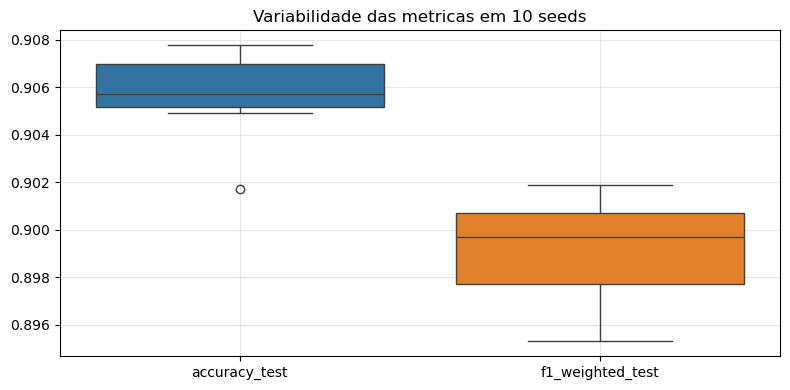

In [72]:
# ETAPA 1 - Escolher a melhor configuracao observada ate aqui.
best_opt = df_opt.sort_values('f1_weighted_test', ascending=False).iloc[0]
print('Melhor configuracao encontrada:')
display(best_opt.to_frame(name='valor'))

# ETAPA 2 - Repetir treino varias vezes com seeds diferentes (analise de estabilidade).
seed_runs = list(range(10))
rows_repeat = []

for sd in seed_runs:
    r = run_experiment(
        epochs_cfg=int(best_opt.get('epochs', 100)),
        lr_cfg=float(best_opt.get('lr', 0.01 if best_opt['optimizer'] == 'sgd' else 0.001)),
        hidden_cfg=int(best_opt.get('hidden_neurons', 24)),
        batch_cfg=int(best_opt.get('batch_size', 64)),
        momentum_cfg=float(best_opt.get('momentum', 0.5)),
        normalize_cfg=bool(best_opt['normalize']),
        optimizer_name=str(best_opt['optimizer']),
        seed=int(sd)
    )
    rows_repeat.append({
        'seed': sd,
        'accuracy_test': r['report']['accuracy'],
        'f1_weighted_test': r['report']['weighted avg']['f1-score']
    })

# ETAPA 3 - Estimar media e IC95% (t de Student, n pequeno).
df_repeat = pd.DataFrame(rows_repeat)
display(df_repeat)

n = len(df_repeat)
acc_mean = df_repeat['accuracy_test'].mean()
acc_std = df_repeat['accuracy_test'].std(ddof=1)
f1_mean = df_repeat['f1_weighted_test'].mean()
f1_std = df_repeat['f1_weighted_test'].std(ddof=1)

# Para n=10, usar t-critico melhora a estimativa em relacao ao z=1.96.
from scipy.stats import t
t_crit = t.ppf(0.975, df=n-1)
ci95_acc = t_crit * acc_std / np.sqrt(n)
ci95_f1 = t_crit * f1_std / np.sqrt(n)

print(f"\nAcuracia media em {n} seeds: {acc_mean:.4f} +/- {ci95_acc:.4f} (IC95)")
print(f"F1-weighted medio em {n} seeds: {f1_mean:.4f} +/- {ci95_f1:.4f} (IC95)")

resumo = pd.DataFrame({
    'metrica': ['accuracy_test', 'f1_weighted_test'],
    'media': [acc_mean, f1_mean],
    'desvio_padrao': [acc_std, f1_std],
    'ic95_meia_largura': [ci95_acc, ci95_f1],
    'ic95_inf': [acc_mean - ci95_acc, f1_mean - ci95_f1],
    'ic95_sup': [acc_mean + ci95_acc, f1_mean + ci95_f1],
})
display(resumo)

# ETAPA 4 - Avaliar estabilidade do desempenho (robustez experimental).
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_repeat[['accuracy_test', 'f1_weighted_test']])
plt.title('Variabilidade das metricas em 10 seeds')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Comentarios

Essa análise foi importante porque mostrou que a melhor configuração encontrada não dependeu de uma execução isolada para parecer boa. Mesmo repetindo o treinamento com 10 seeds diferentes, os resultados ficaram bastante concentrados: a acurácia variou de 0.9017 a 0.9081, enquanto o F1-weighted ficou entre 0.8952 e 0.9035. Essa pouca variação sugere que o modelo manteve um comportamento estável, ou seja, o desempenho não ficou à mercê da inicialização aleatória dos pesos.

Além disso, eu não quis olhar apenas para a média das métricas, mas também para a incerteza associada a essa média. Como a análise foi feita com apenas 10 execuções, optei por usar a distribuição t de Student na construção do intervalo de confiança, em vez de usar diretamente a aproximação normal. Esse detalhe é importante porque, com amostras pequenas, a t de Student representa melhor a variabilidade dos resultados e evita passar uma confiança exagerada na estimativa. Então, além de o modelo ter apresentado baixa dispersão, a forma de resumir os resultados também foi mais adequada do ponto de vista estatístico.

No fim, essa etapa fortalece bastante a conclusão do trabalho, porque mostra duas coisas ao mesmo tempo: primeiro, que a configuração escolhida teve bom desempenho de forma recorrente; segundo, que essa conclusão foi sustentada com um tratamento estatístico mais cuidadoso. Assim, a escolha final não fica baseada apenas no maior valor observado, mas em uma combinação de bom desempenho, estabilidade entre execuções e intervalo de confiança calculado de forma mais apropriada.